In [1]:
import awkward as ak
import numpy as np
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
from coffea.nanoevents import NanoEventsFactory, TreeMakerSchema

In [2]:
samples = [
    {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "root://cmseos.fnal.gov//store/user/lpcdarkqcd/tchannel_UL/2018/Full/PrivateSamples/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000/0_RA2AnalysisTree.root"},
    {"rinv": 5, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.5$", "fname": "root://cmseos.fnal.gov//store/user/lpcdarkqcd/tchannel_UL/2018/Full/PrivateSamples/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p5_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000/0_RA2AnalysisTree.root"},
    {"rinv": 7, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.7$", "fname": "root://cmseos.fnal.gov//store/user/lpcdarkqcd/tchannel_UL/2018/Full/PrivateSamples/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p7_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000/0_RA2AnalysisTree.root"},
]

In [3]:
for sample in samples:
    sample["events"] = NanoEventsFactory.from_root(
        file=sample["fname"],
        treepath="TreeMaker2/PreSelection",
        schemaclass=TreeMakerSchema,
        metadata={"dataset": sample["legname"]},
    ).events()

In [5]:
for sample in samples:
    keys = sample["events"][0].tolist().keys()
    for k in keys: 
        print(k)
    break

RunNum
LumiBlockNum
EvtNum
BadChargedCandidateFilter
BadPFMuonDzFilter
BadPFMuonFilter
BTagsDeepCSV
BTagsDeepCSVJECdown
BTagsDeepCSVJECup
BTagsDeepCSVJERdown
BTagsDeepCSVJERup
CaloMET
CaloMETPhi
CrossSection
CSCTightHaloFilter
DeltaPhi1
DeltaPhi1_AK8
DeltaPhi1JECdown
DeltaPhi1JECup
DeltaPhi1JERdown
DeltaPhi1JERup
DeltaPhi2
DeltaPhi2_AK8
DeltaPhi2JECdown
DeltaPhi2JECup
DeltaPhi2JERdown
DeltaPhi2JERup
DeltaPhi3
DeltaPhi3JECdown
DeltaPhi3JECup
DeltaPhi3JERdown
DeltaPhi3JERup
DeltaPhi4
DeltaPhi4JECdown
DeltaPhi4JECup
DeltaPhi4JERdown
DeltaPhi4JERup
DeltaPhiMin_AK8
ecalBadCalibFilter
EcalDeadCellBoundaryEnergyFilter
EcalDeadCellTriggerPrimitiveFilter
eeBadScFilter
fixedGridRhoFastjetAll
GenHT
GenMET
GenMETPhi
GenMHT
GenMHTPhi
GenMT2_AK8
globalSuperTightHalo2016Filter
globalTightHalo2016Filter
hasGenPromptPhoton
HBHEIsoNoiseFilter
HBHENoiseFilter
hfNoisyHitsFilter
HT
HT5
HT5JECdown
HT5JECup
HT5JERdown
HT5JERup
HTJECdown
HTJECup
HTJERdown
HTJERup
isoElectronTracks
isoMuonTracks
isoPionTracks


In [9]:
for sample in samples:
    events = sample["events"]
    for o in ["GenParticles", "GenJetsAK8", "JetsConstituents", "JetsAK8"]:
        keys = events[o][:,0:2].tolist()[0][0].keys()
        print(o)
        print(keys)
    
        for k in keys: 
            #if type(getattr(events[o][:,0:2], k)) == type(events[o][:,0:2].darkHadronJets): continue
            events[o+k] = ak.nan_to_num(getattr(events[o][:,0:2], k), nan=0)

#      events["darkHadronJetMassSome"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].darkHadronJets.mass,nan=0)
#      events["darkHadronJetN"] = ak.max(events["darkHadronJetMassAll"], axis=2)
#      events["darkHadronJetMassAllAvg"] = ak.mean(events["darkHadronJetMassAll"], axis=2)
#      some_mask = events["GenJetsAK8"][:,0:2].darkHadronJetsMultiplicity>int(0.6*sample["mdark"])
#      events["darkHadronJetMassSome"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].darkHadronJets.mass[some_mask],nan=0)
#      events["darkHadronJetMassSomeMax"] = ak.max(events["darkHadronJetMassSome"], axis=2)
#      events["darkHadronJetMassSomeAvg"] = ak.mean(events["darkHadronJetMassSome"], axis=2)


GenParticles
dict_keys(['pt', 'eta', 'phi', 'energy', 'Charge', 'ParentId', 'ParentIdx', 'PdgId', 'Status'])
GenJetsAK8
dict_keys(['pt', 'eta', 'phi', 'energy', 'MT2JetsID', 'darkPtFrac', 'hvCategory', 'multiplicity', 'softDropMass'])
JetsConstituents
dict_keys(['pt', 'eta', 'phi', 'energy', 'PdgId', 'PuppiWeight', 'dxy', 'dxysig', 'dz', 'dzsig'])
JetsAK8
dict_keys(['pt', 'eta', 'phi', 'energy', 'DeepMassDecorrelTagHbbvsQCD', 'DeepMassDecorrelTagTvsQCD', 'DeepMassDecorrelTagWvsQCD', 'DeepMassDecorrelTagZHbbvsQCD', 'DeepMassDecorrelTagZbbvsQCD', 'DeepMassDecorrelTagZvsQCD', 'DeepMassDecorrelTagbbvsLight', 'DeepTagHbbvsQCD', 'DeepTagTvsQCD', 'DeepTagWvsQCD', 'DeepTagZbbvsQCD', 'DeepTagZvsQCD', 'ID', 'NsubjettinessTau1', 'NsubjettinessTau2', 'NsubjettinessTau3', 'NsubjettinessTau4', 'NsubjettinessTau5', 'NumBhadrons', 'NumChadrons', 'axismajor', 'axisminor', 'chargedEmEnergyFraction', 'chargedHadronEnergyFraction', 'chargedHadronMultiplicity', 'chargedMultiplicity', 'constituentsIndexCoun

In [37]:
def get_values(var,sample):
    return ak.flatten(sample["events"][var],axis=None)

def fill_hist(var,label,samples):
    hists = {}
    for sample in samples:
        minimum = np.min(get_values(var,sample)) - 1
        maximum = np.max(get_values(var,sample)) + 1
        bins = 10
        if "eta" in var: bins = 24
        if "phi" in var: bins = 24
        if "pt" in var: bins = 100
        if "mult" in var: bins = 10
        if "subjetiness" in var: bins = 100
        print("bins ", var, int(bins))
        h = (
            hist.Hist.new
            .Reg(int(bins), minimum, maximum, label=label)
            .Double()
        )
        h.fill(get_values(var,sample),weight=0.5)
        hists[sample["legname"]] = h
        stat = hist.accumulators.Mean().fill(get_values(var,sample))
        print("{} {} {}".format(var, sample["rinv"], np.sqrt(stat.variance)/stat.value))
    return hists


In [38]:
# histnames = [
#     ("darkHadronJetMassAll",r"$m(j_{\\text{dark}}^{\\text{gen}})$ [GeV]"),
#     ("darkHadronJetMassAllMax",r"$\\text{max}(m(j_{\\text{dark}}^{\\text{gen}}))$ [GeV]"),
#     ("darkHadronJetMassAllAvg",r"$\\langle m(j_{\\text{dark}}^{\\text{gen}}) \\rangle$ [GeV]"),
#     ("darkHadronJetMassSome",r"$m(j_{\\text{dark}}^{\\text{gen}})$ [GeV]"),
#     ("darkHadronJetMassSomeMax",r"$\\text{max}(m(j_{\\text{dark}}^{\\text{gen}}))$ [GeV]"),
#     ("darkHadronJetMassSomeAvg",r"$\\langle m(j_{\\text{dark}}^{\\text{gen}}) \\rangle$ [GeV]"),
# ]
# allhists = []
# for v,l in histnames:
#     allhists.append((v,fill_hist(v,l,samples)))
    
allhists = []
print(keys)
histnames = keys
for o in ["GenParticles", "GenJetsAK8", "JetsConstituents", "JetsAK8"]: 
    for n in histnames:
        #print (samples[0]["events"].tolist())
        print(o,n)
#         print(hasattr(samples[0]["events"][0], o + n))
        if not hasattr(samples[0]["events"][0], o + n): continue
        allhists.append((o+n,fill_hist(o+n,o+n,samples)))
    
# print(allhists)


dict_keys(['pt', 'eta', 'phi', 'energy', 'DeepMassDecorrelTagHbbvsQCD', 'DeepMassDecorrelTagTvsQCD', 'DeepMassDecorrelTagWvsQCD', 'DeepMassDecorrelTagZHbbvsQCD', 'DeepMassDecorrelTagZbbvsQCD', 'DeepMassDecorrelTagZvsQCD', 'DeepMassDecorrelTagbbvsLight', 'DeepTagHbbvsQCD', 'DeepTagTvsQCD', 'DeepTagWvsQCD', 'DeepTagZbbvsQCD', 'DeepTagZvsQCD', 'ID', 'NsubjettinessTau1', 'NsubjettinessTau2', 'NsubjettinessTau3', 'NsubjettinessTau4', 'NsubjettinessTau5', 'NumBhadrons', 'NumChadrons', 'axismajor', 'axisminor', 'chargedEmEnergyFraction', 'chargedHadronEnergyFraction', 'chargedHadronMultiplicity', 'chargedMultiplicity', 'constituentsIndexCounts', 'doubleBDiscriminator', 'ecfC2b1', 'ecfC2b2', 'ecfD2b1', 'ecfD2b2', 'ecfFullC2b1', 'ecfFullC2b2', 'ecfFullD2b1', 'ecfFullD2b2', 'ecfFullM2b1', 'ecfFullM2b2', 'ecfFullN2b1', 'ecfFullN2b2', 'ecfM2b1', 'ecfM2b2', 'ecfN2b1', 'ecfN2b2', 'ecfN3b1', 'ecfN3b2', 'electronEnergyFraction', 'electronMultiplicity', 'genIndex', 'girth', 'hadronFlavor', 'hfEMEnergyF

JetsAK8ecfFullC2b1 3 0.7411651516903012
bins  JetsAK8ecfFullC2b1 10
JetsAK8ecfFullC2b1 5 0.802336861261994
bins  JetsAK8ecfFullC2b1 10
JetsAK8ecfFullC2b1 7 0.9249721101441202
JetsAK8 ecfFullC2b2
bins  JetsAK8ecfFullC2b2 10
JetsAK8ecfFullC2b2 3 1.0385120597993702
bins  JetsAK8ecfFullC2b2 10
JetsAK8ecfFullC2b2 5 1.1314194915976952
bins  JetsAK8ecfFullC2b2 10
JetsAK8ecfFullC2b2 7 1.3023177599299958
JetsAK8 ecfFullD2b1
bins  JetsAK8ecfFullD2b1 10
JetsAK8ecfFullD2b1 3 0.5230152588518786
bins  JetsAK8ecfFullD2b1 10
JetsAK8ecfFullD2b1 5 0.9856587700329393
bins  JetsAK8ecfFullD2b1 10
JetsAK8ecfFullD2b1 7 0.6342466365993494
JetsAK8 ecfFullD2b2
bins  JetsAK8ecfFullD2b2 10
JetsAK8ecfFullD2b2 3 1.178694326853601
bins  JetsAK8ecfFullD2b2 10
JetsAK8ecfFullD2b2 5 1.6023557760391547
bins  JetsAK8ecfFullD2b2 10
JetsAK8ecfFullD2b2 7 1.287295815912352
JetsAK8 ecfFullM2b1
bins  JetsAK8ecfFullM2b1 10
JetsAK8ecfFullM2b1 3 1.4331757131924685
bins  JetsAK8ecfFullM2b1 10
JetsAK8ecfFullM2b1 5 1.5721365326818357

/tmp/ipykernel_39/2801589131.py:24: RuntimeWarning: invalid value encountered in double_scalars
  print("{} {} {}".format(var, sample["rinv"], np.sqrt(stat.variance)/stat.value))


In [39]:
#plt.style.use(hep.style.CMS)
mpl.rcParams.update({
    "axes.labelsize" : 18,
    "legend.fontsize" : 16,
    "xtick.labelsize" : 14,
    "ytick.labelsize" : 14,
    "font.size" : 18,
    "legend.frameon": True,
})
# based on https://github.com/mpetroff/accessible-color-cycles
# red, blue, mauve, orange, purple, gray, 
colors = ["#e42536", "#5790fc", "#964a8b", "#f89c20", "#7a21dd", "#9c9ca1"]
styles = ['--','-.',':',]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

/tmp/ipykernel_39/2588590822.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8,6))


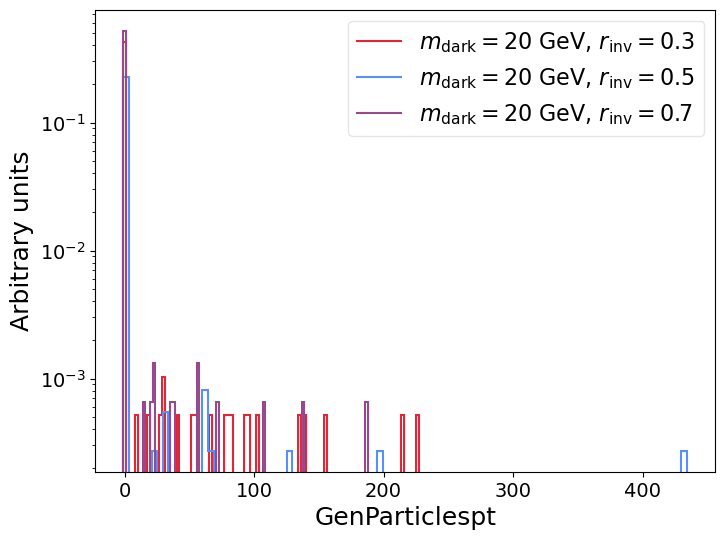

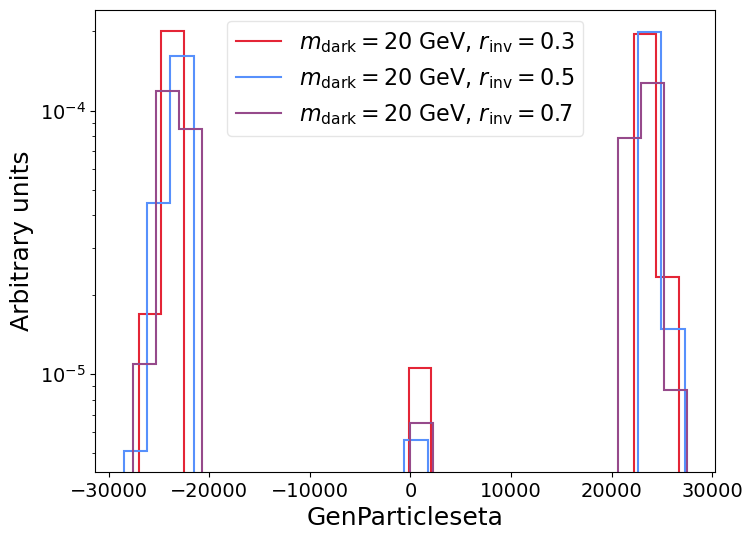

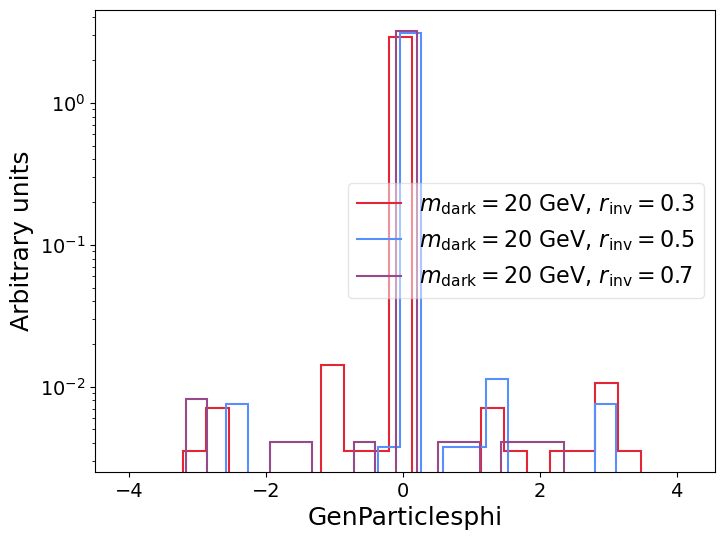

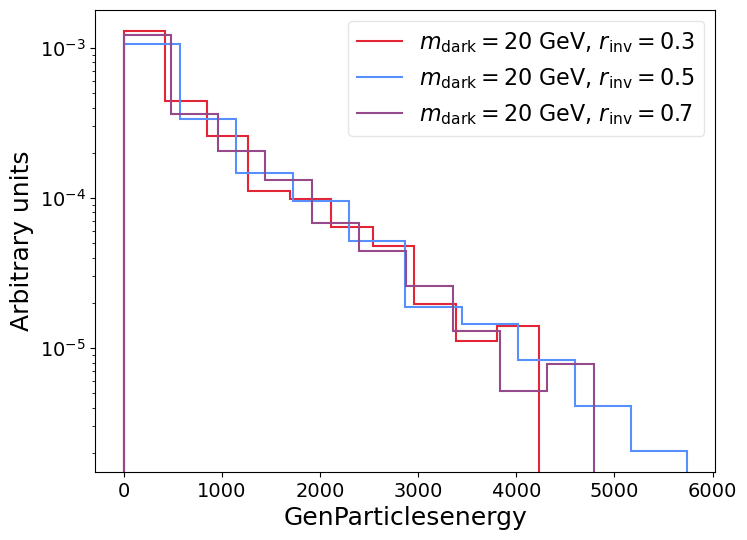

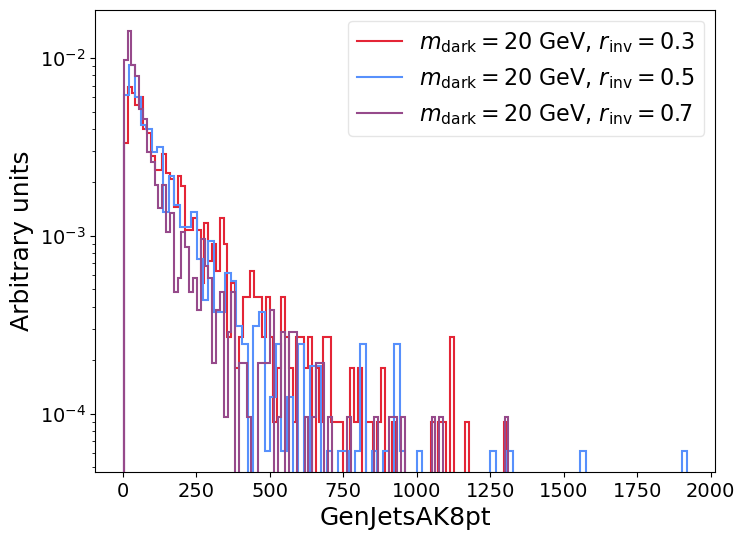

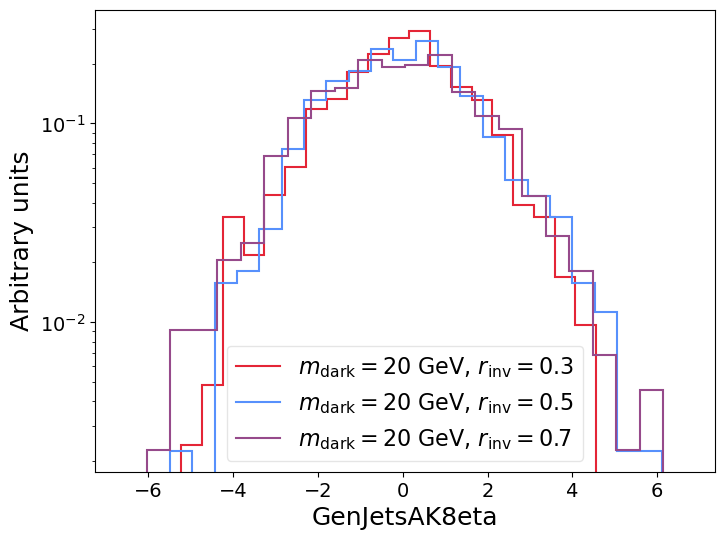

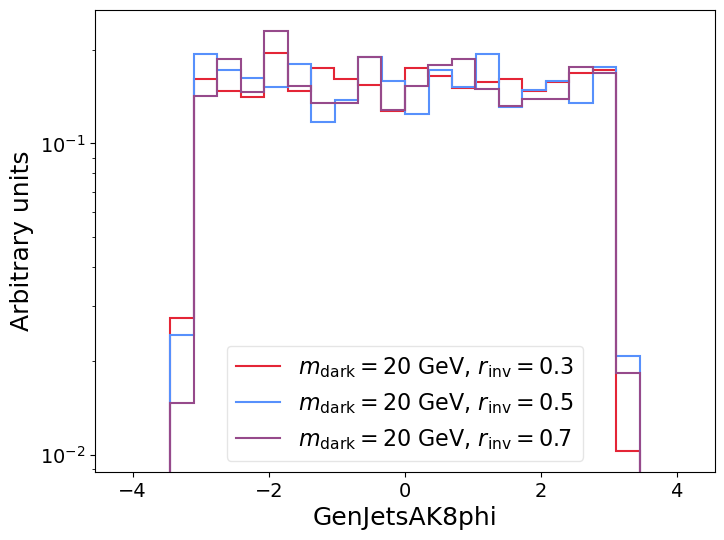

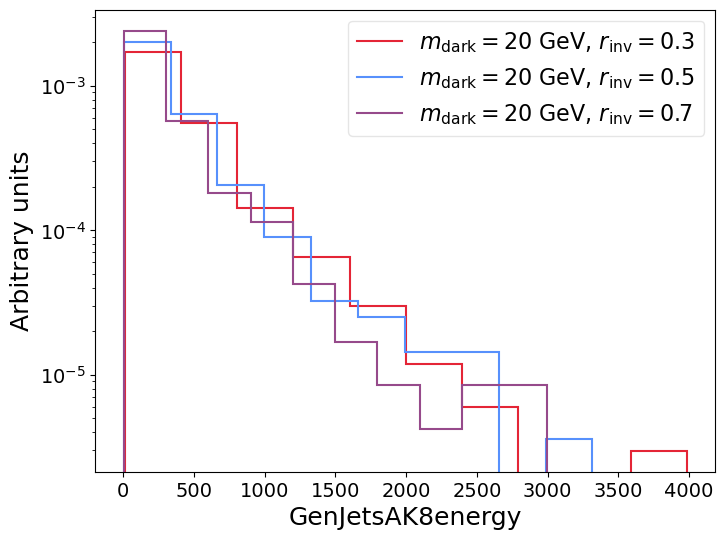

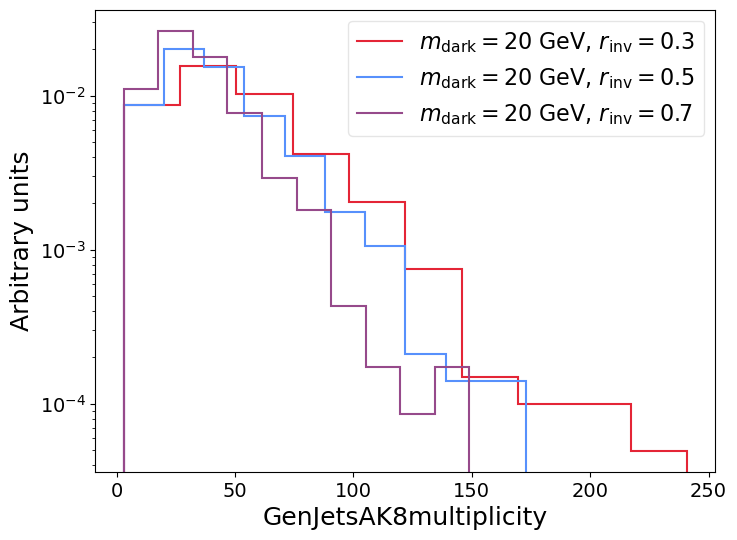

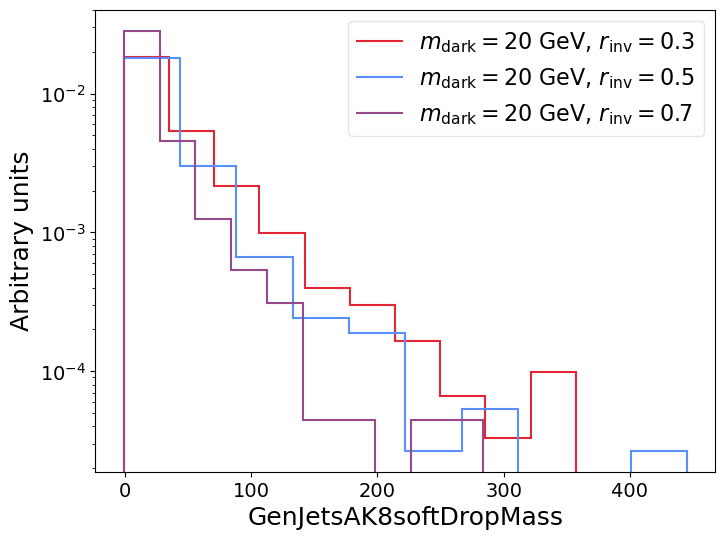

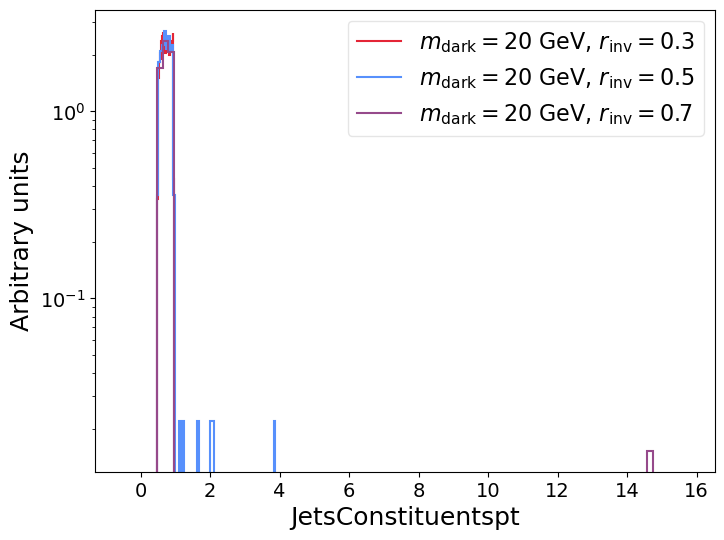

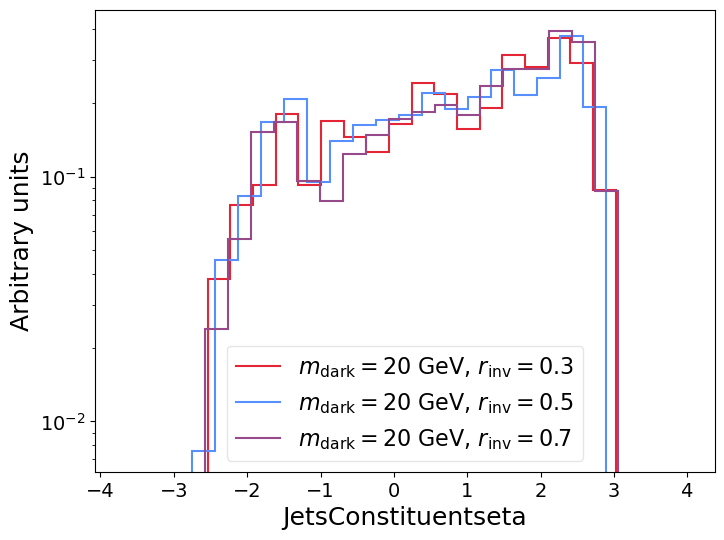

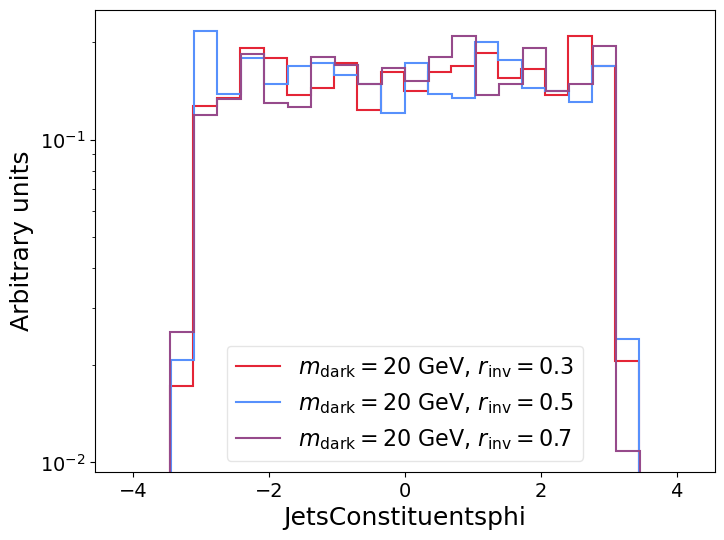

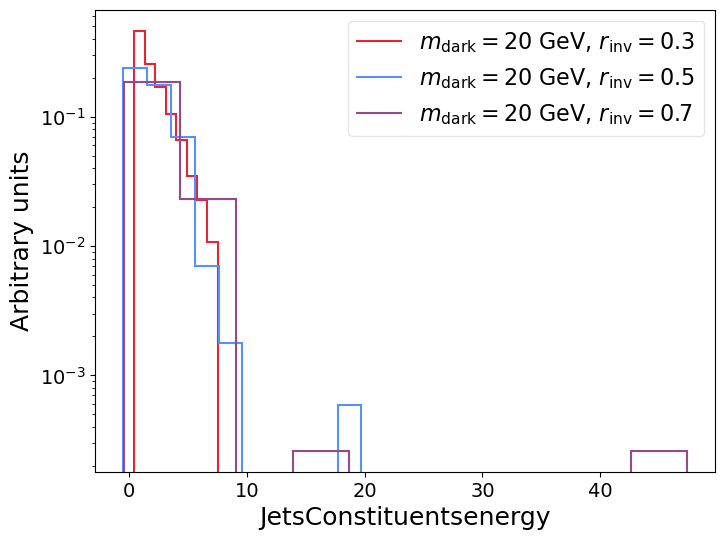

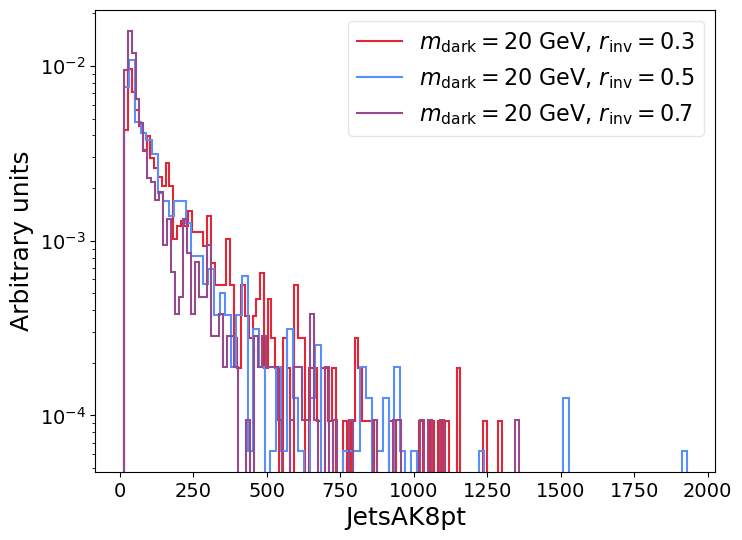

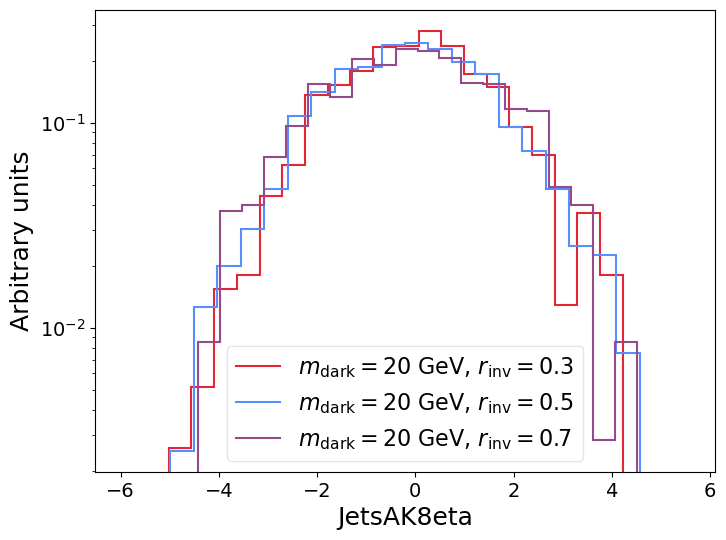

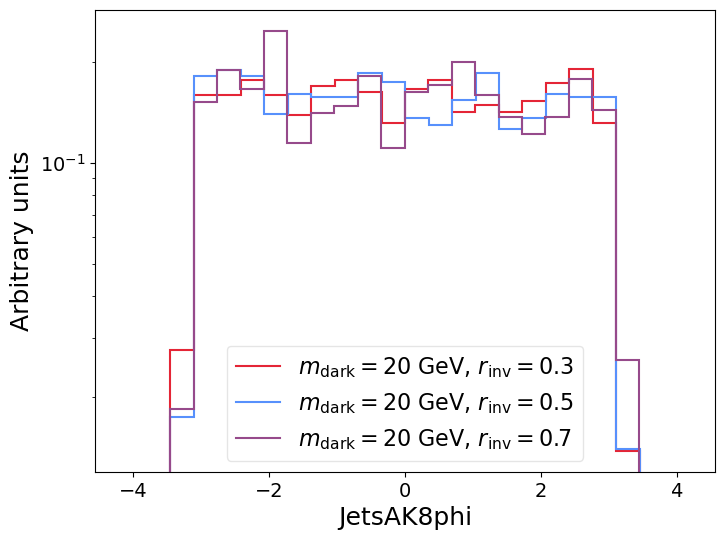

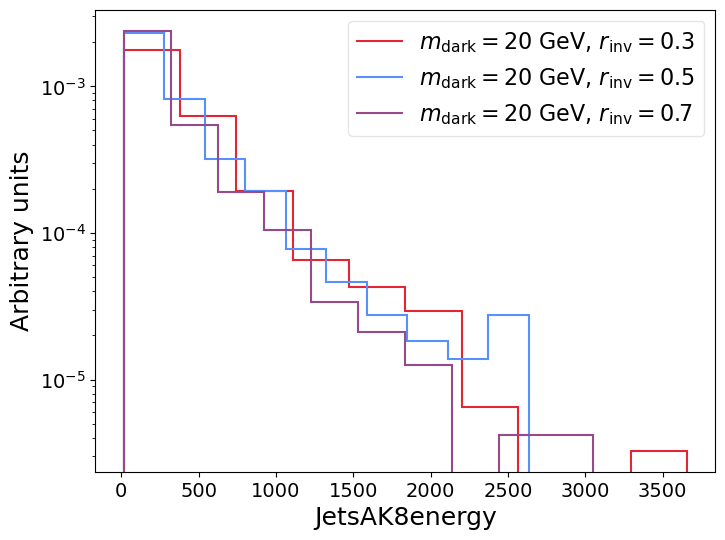

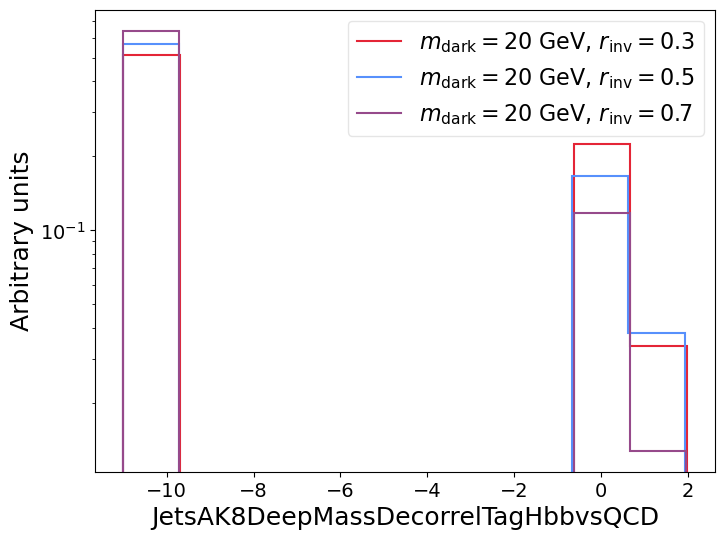

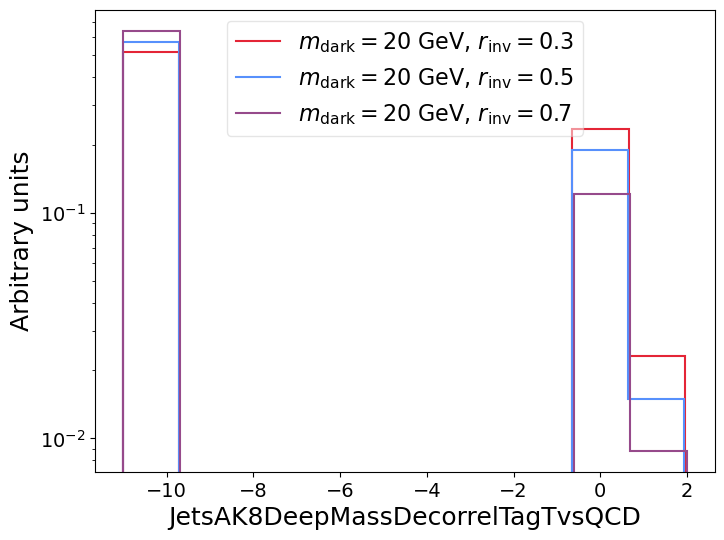

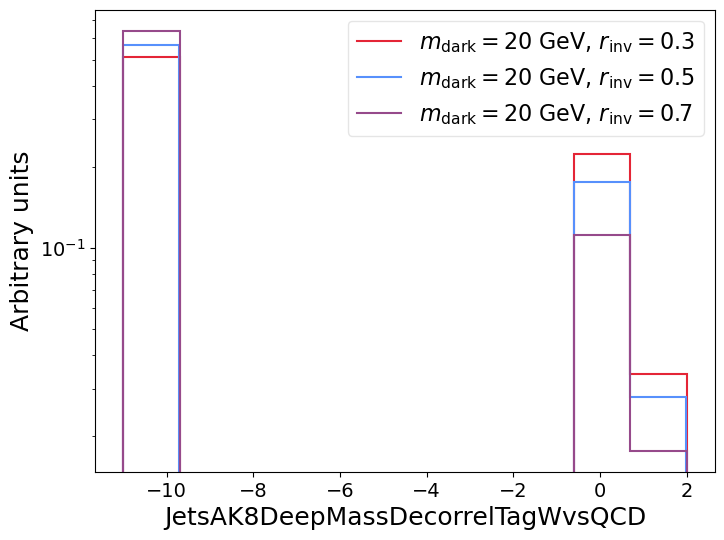

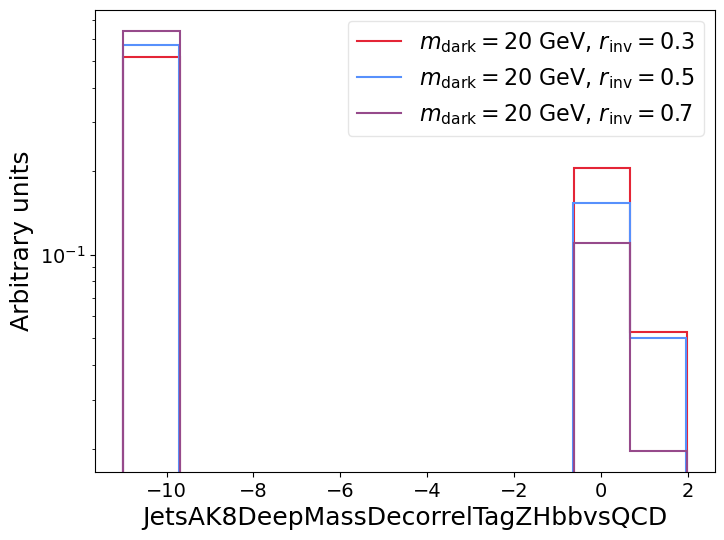

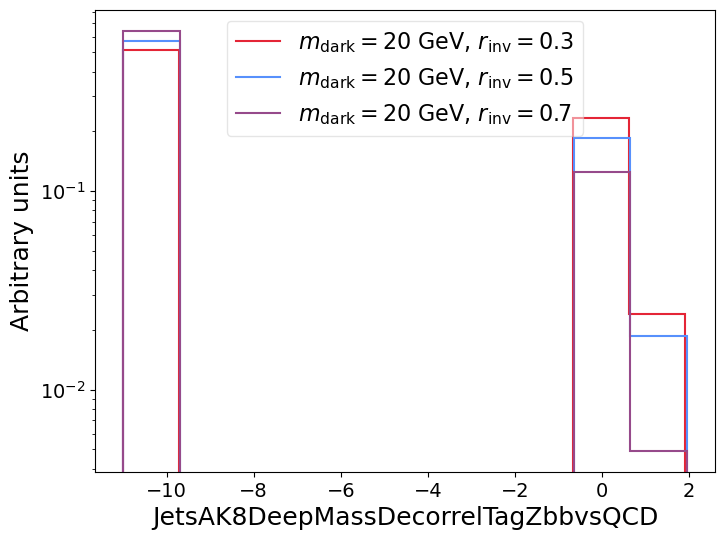

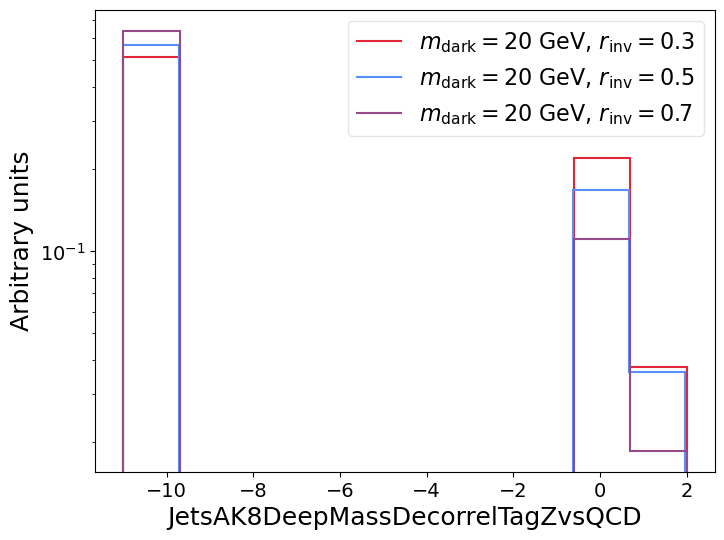

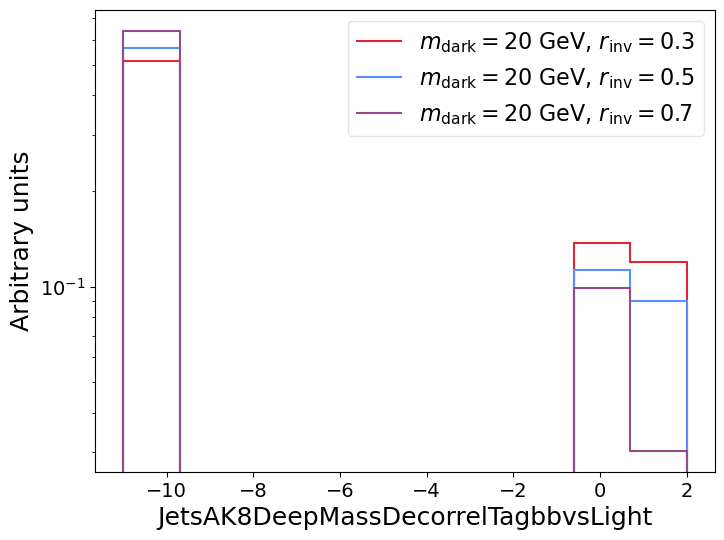

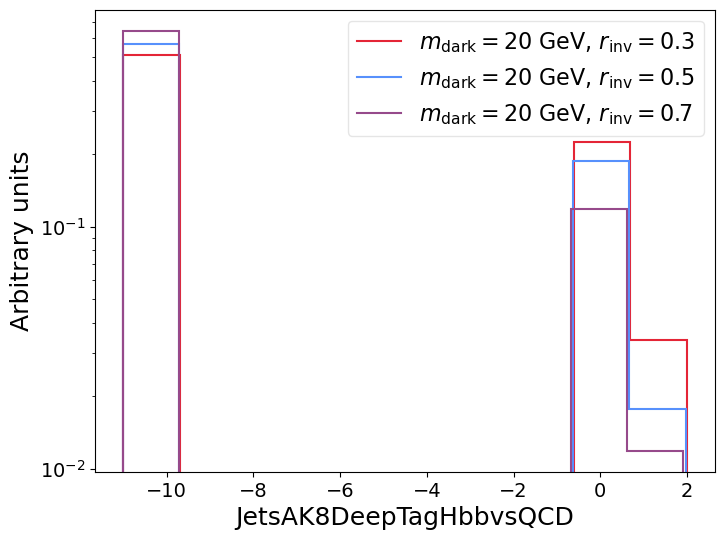

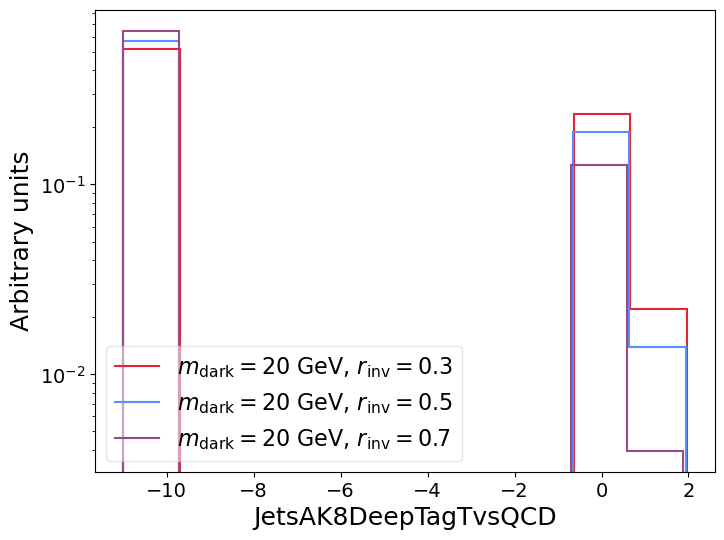

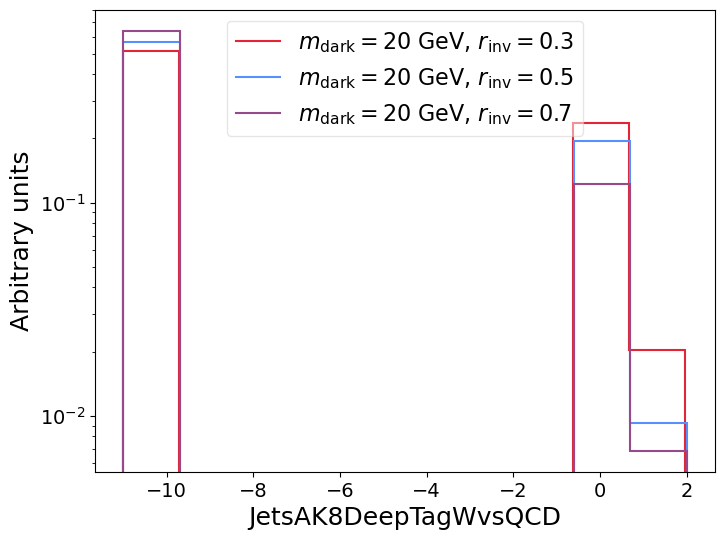

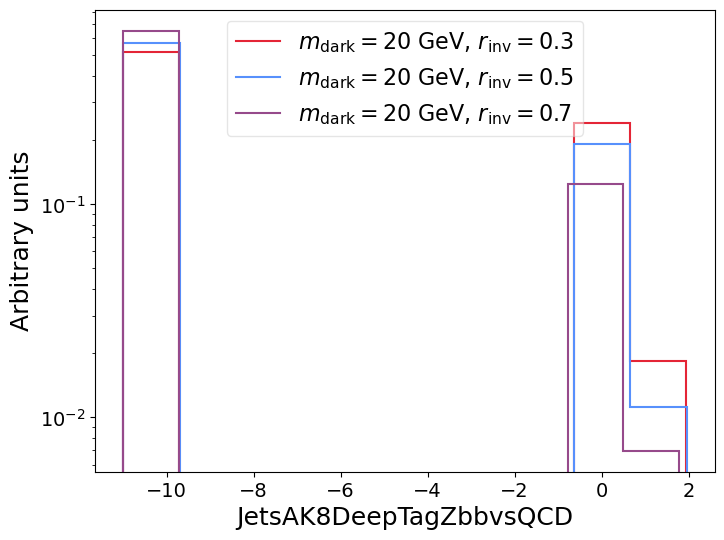

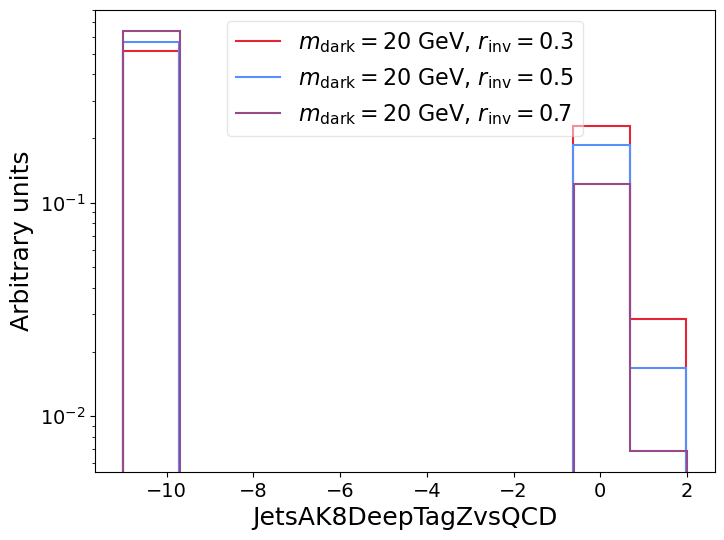

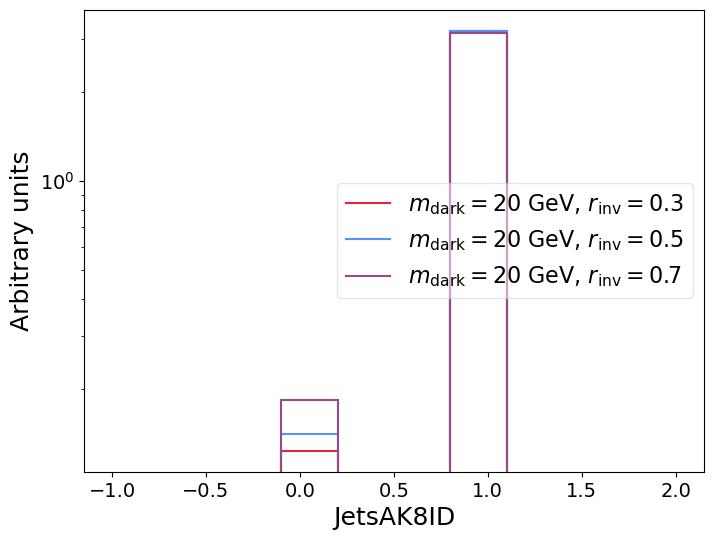

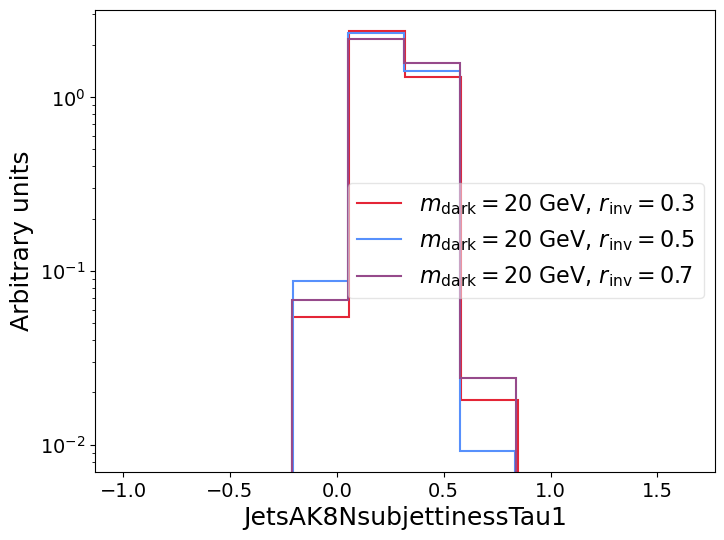

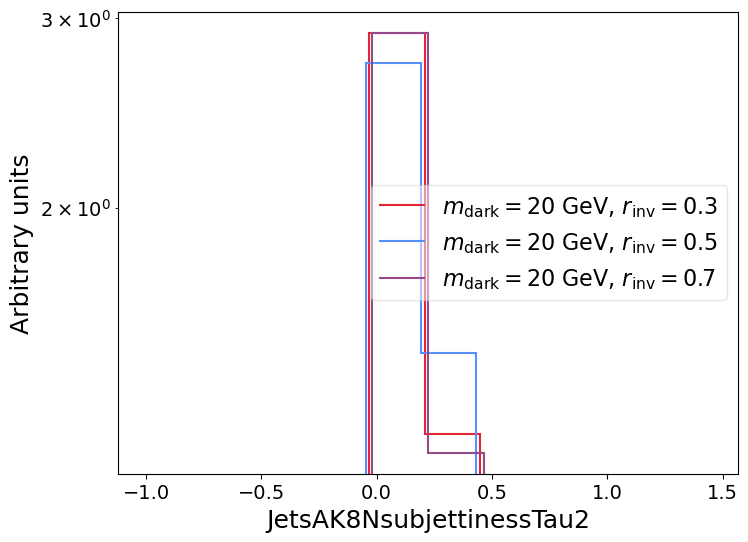

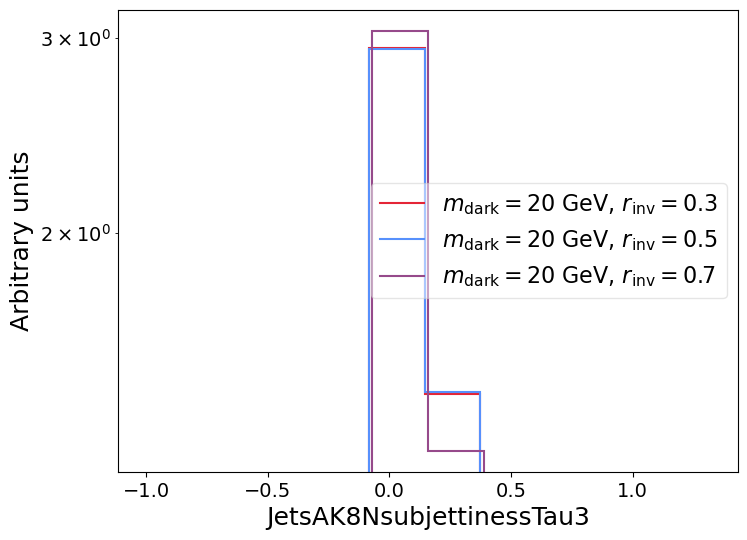

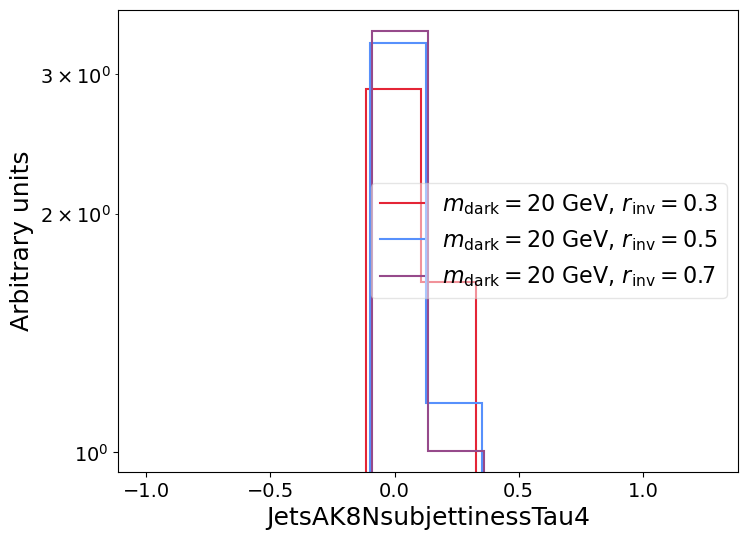

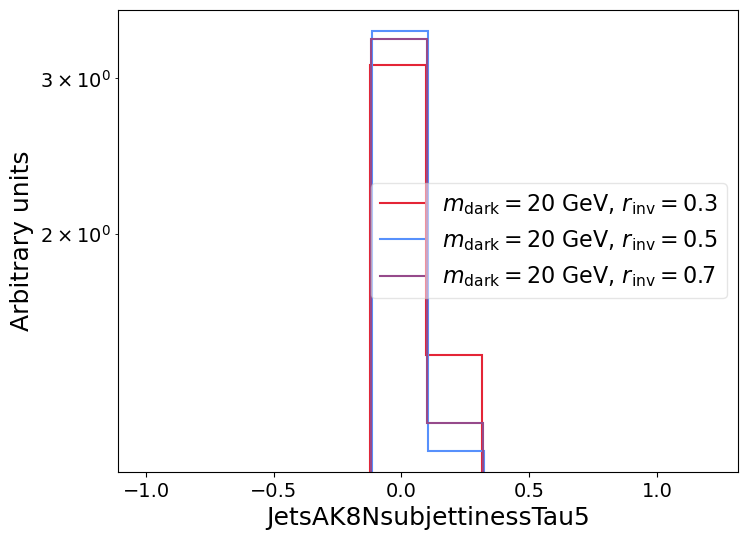

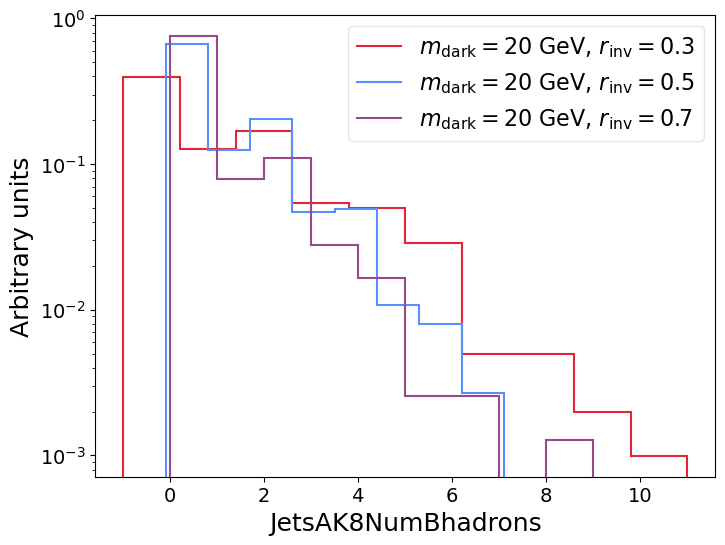

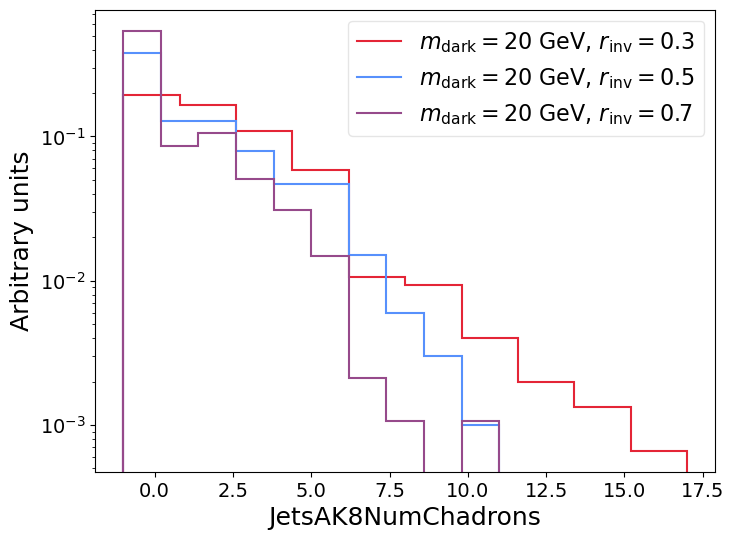

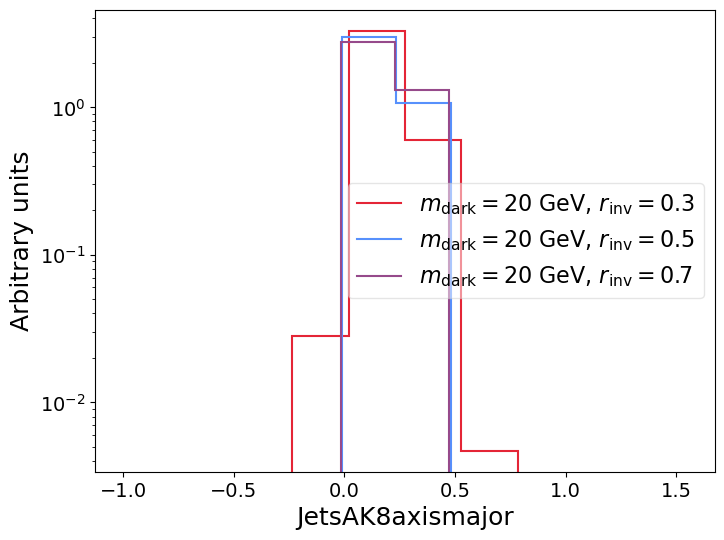

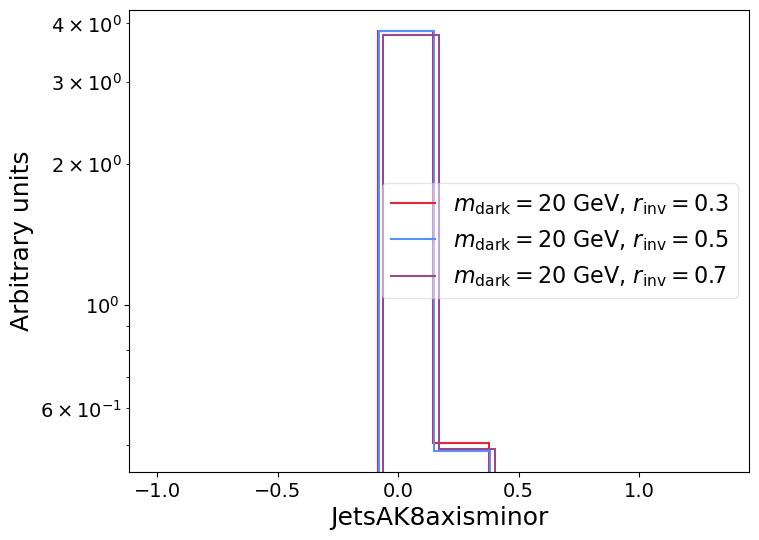

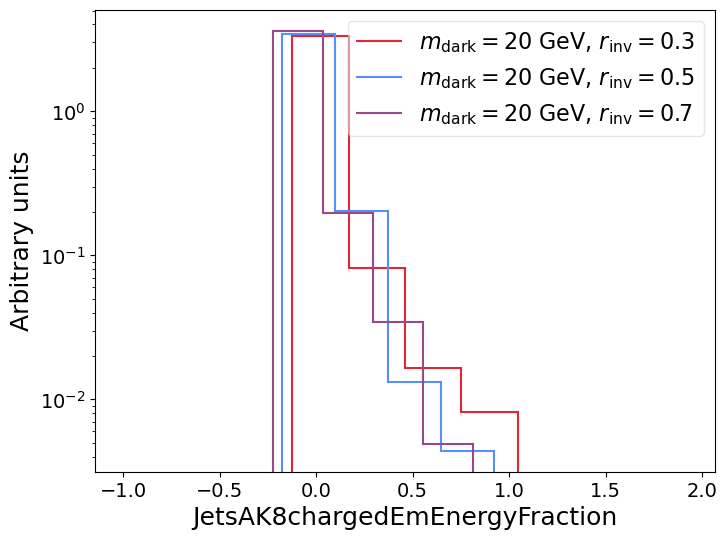

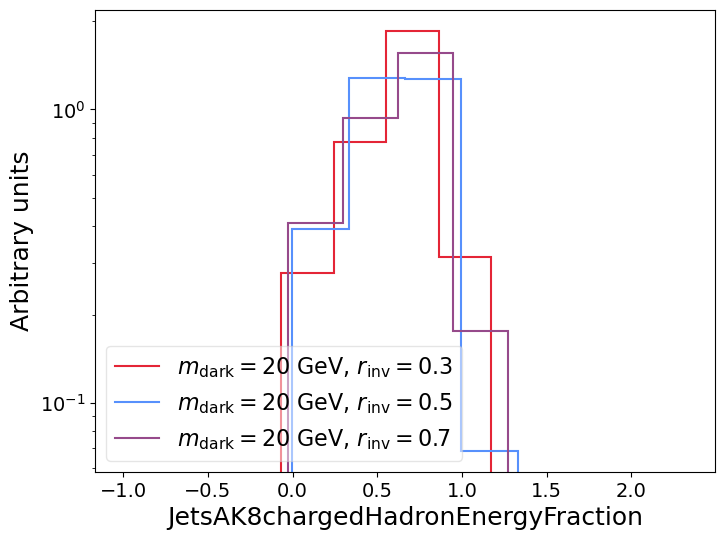

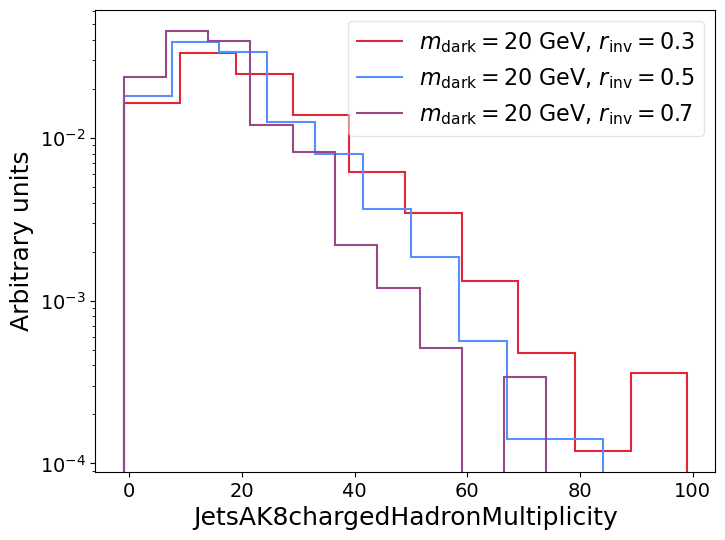

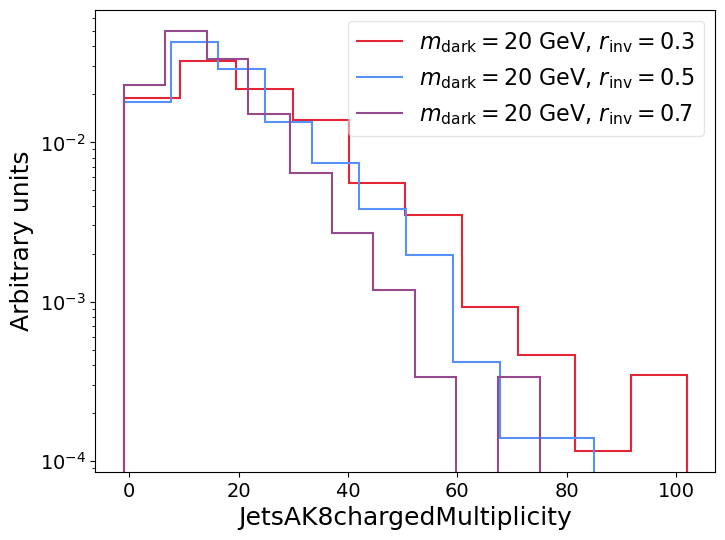

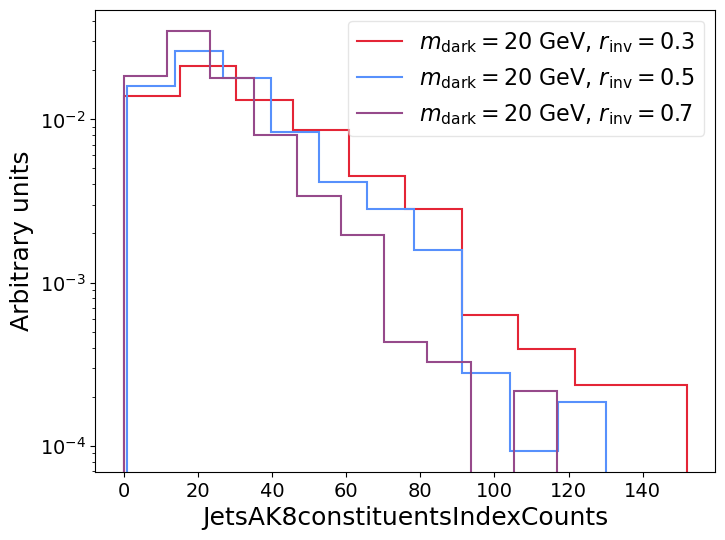

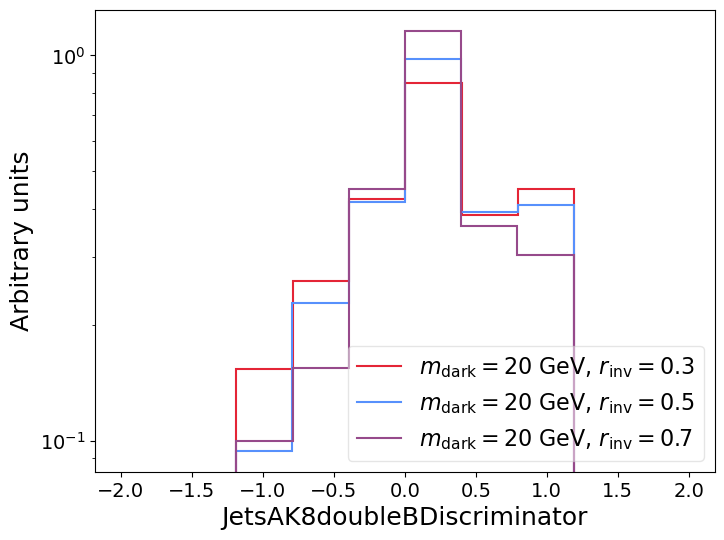

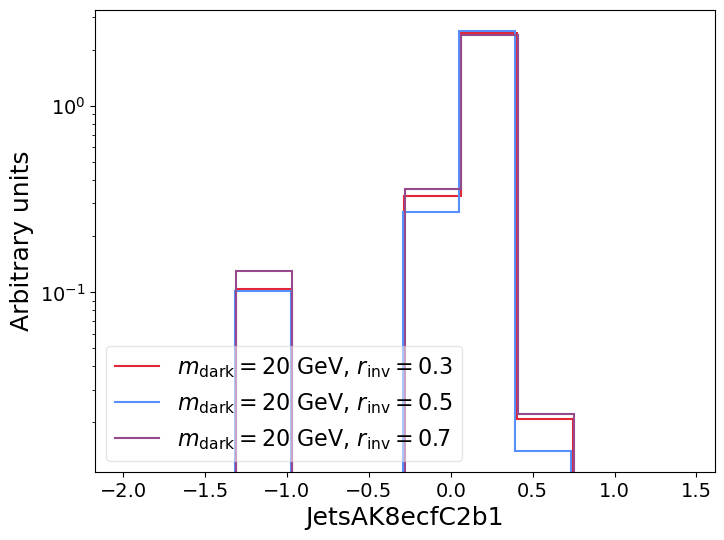

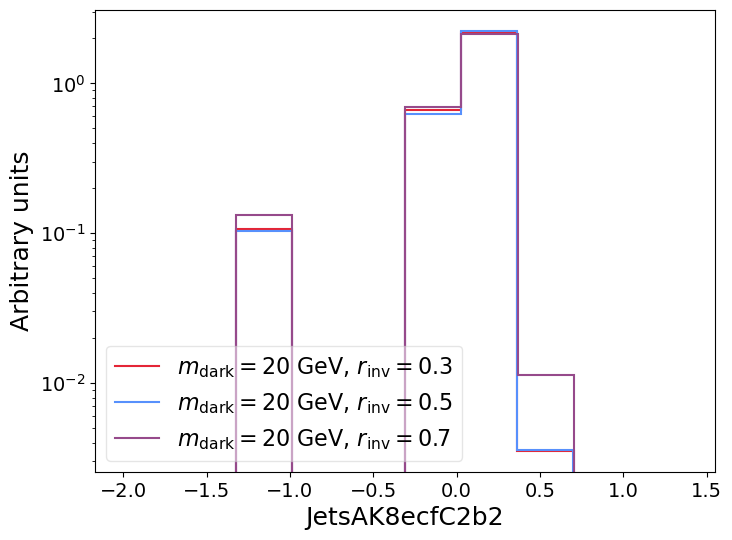

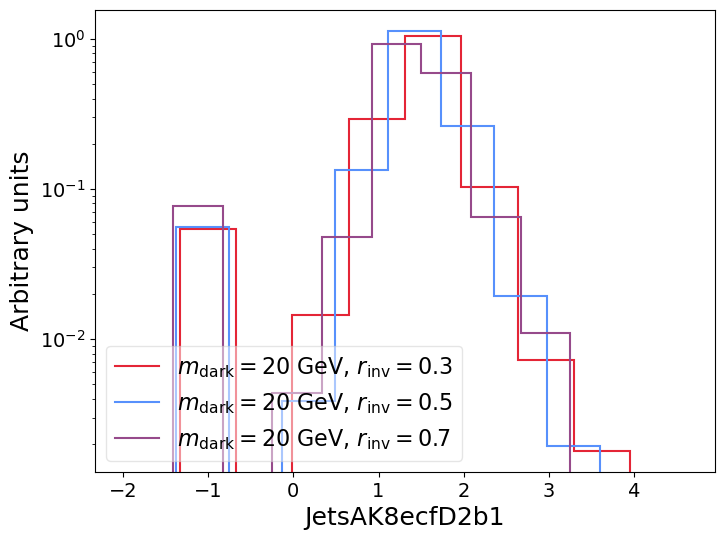

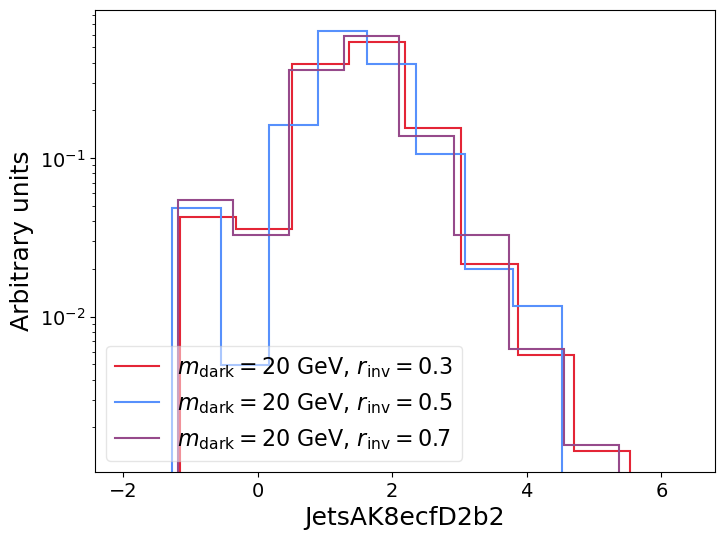

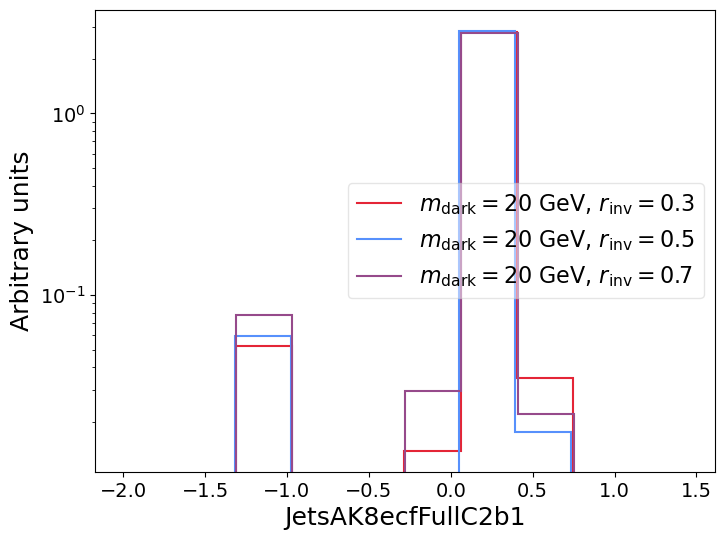

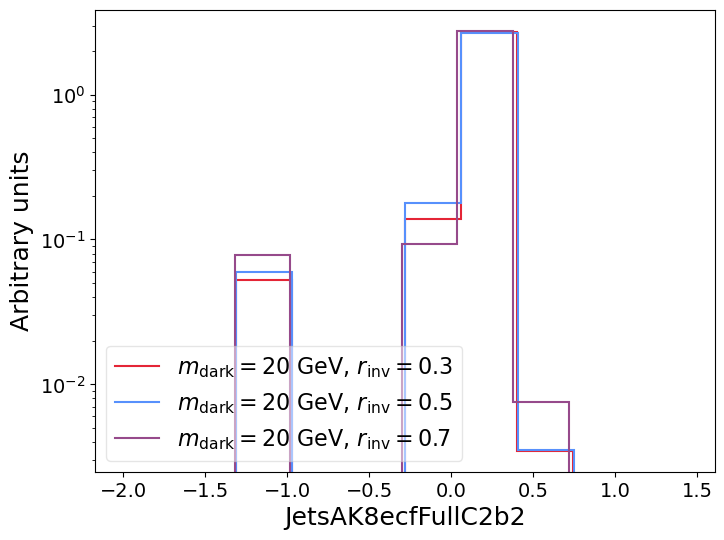

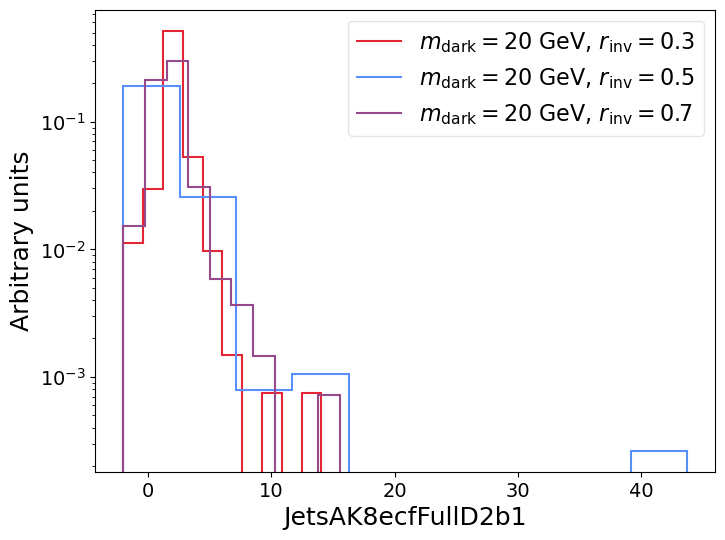

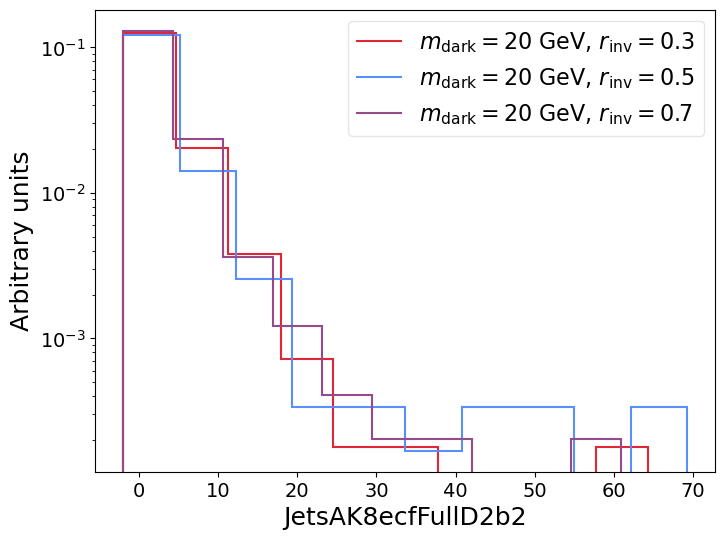

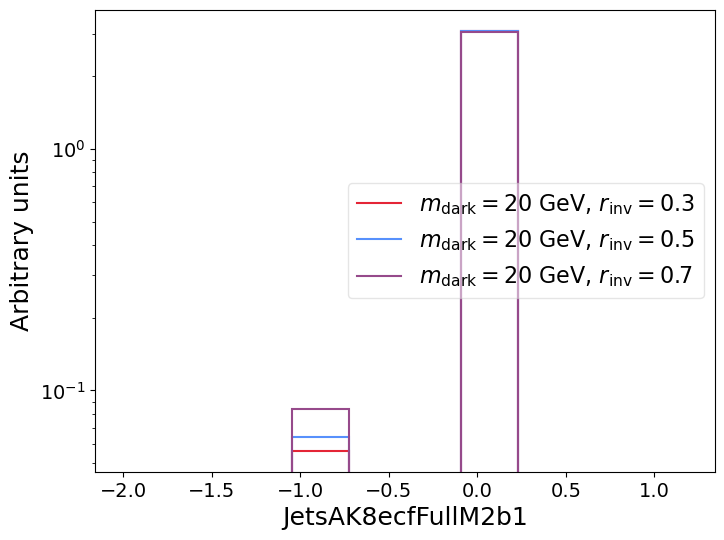

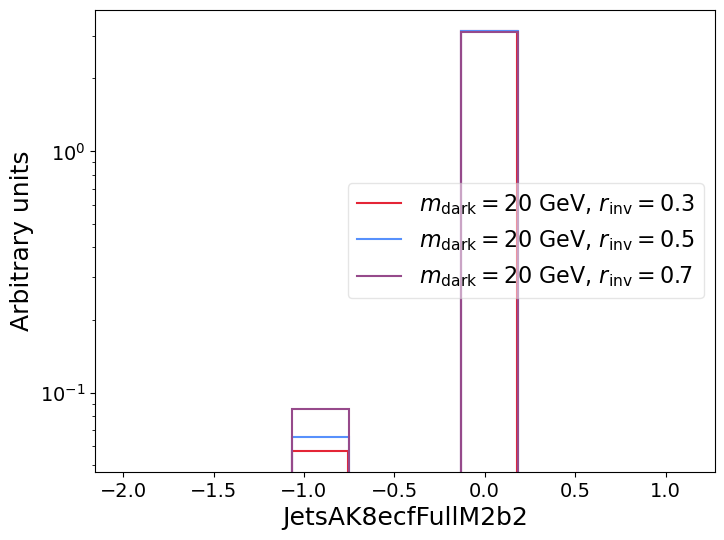

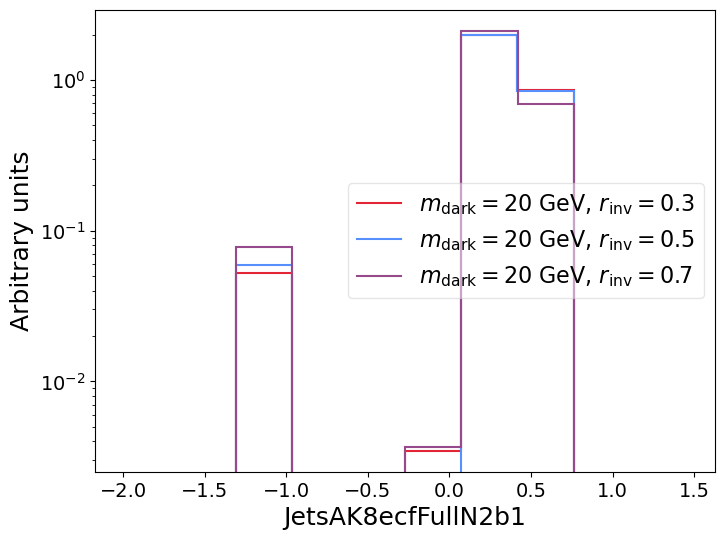

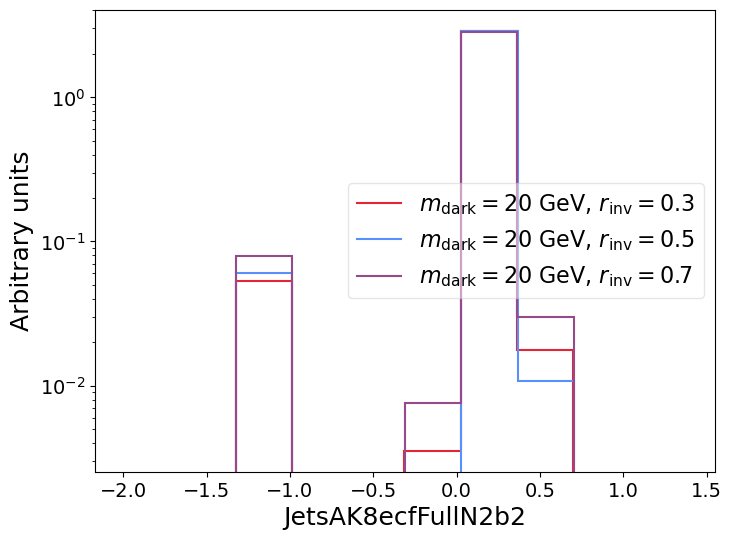

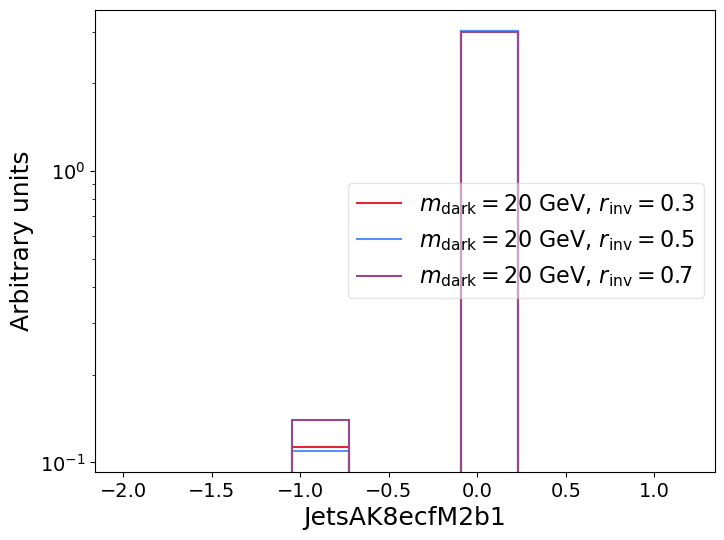

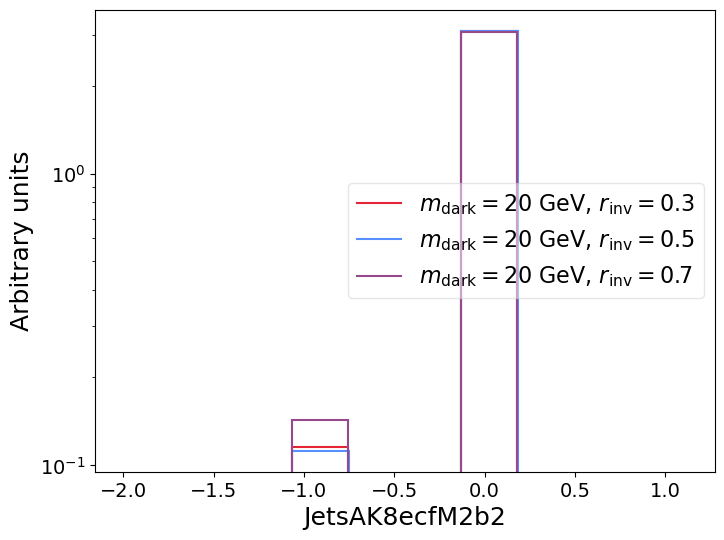

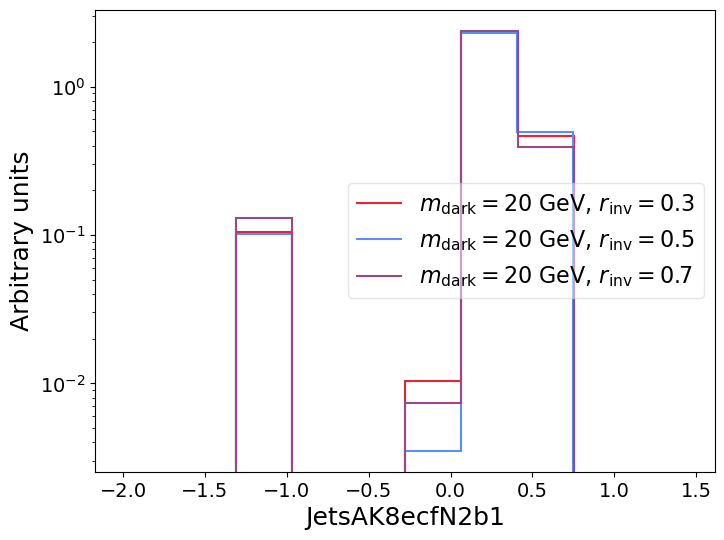

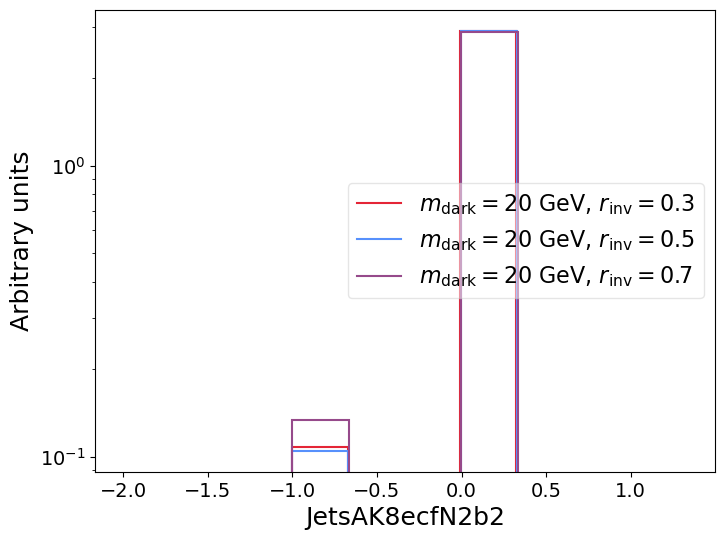

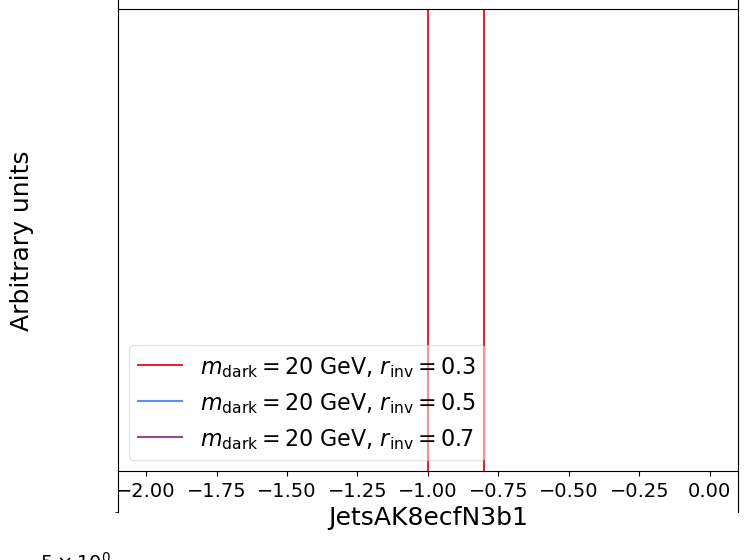

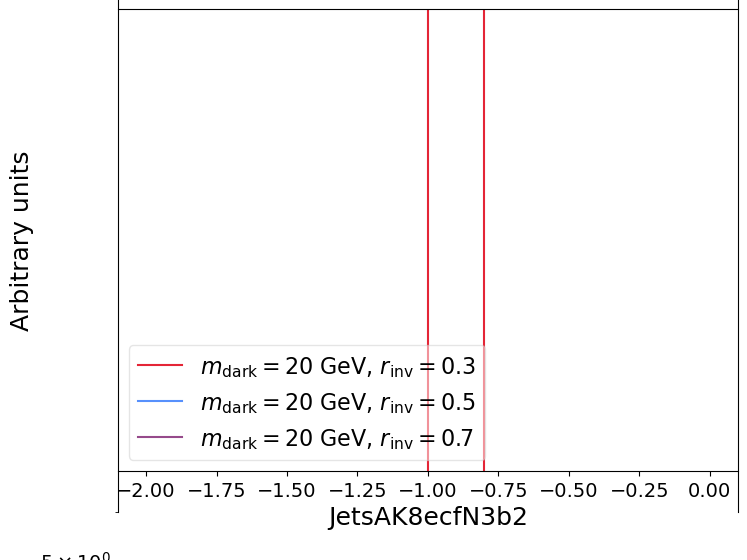

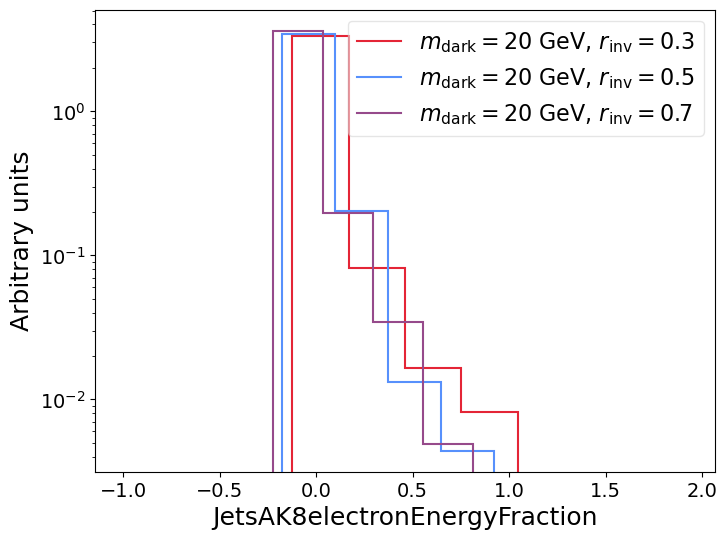

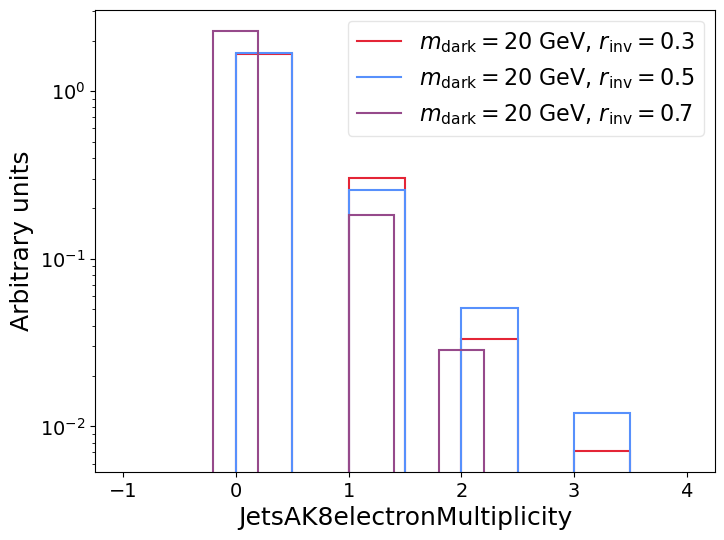

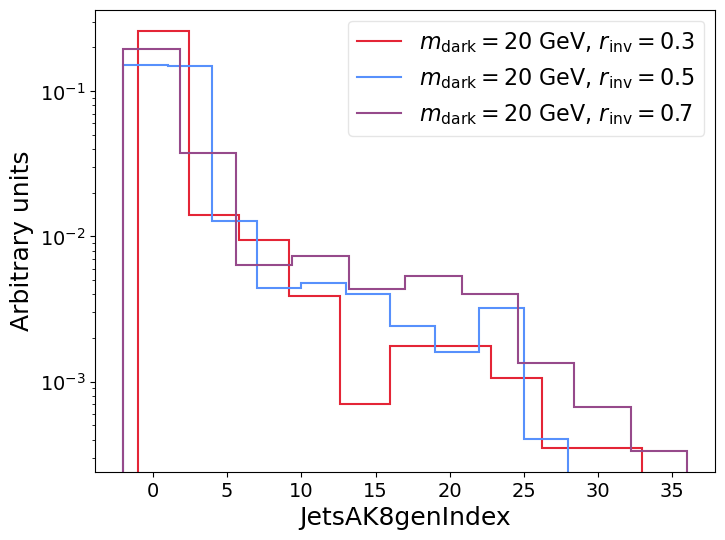

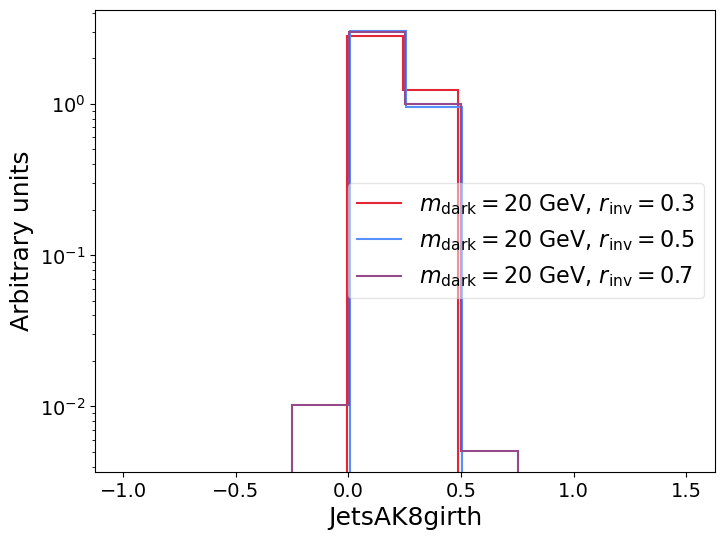

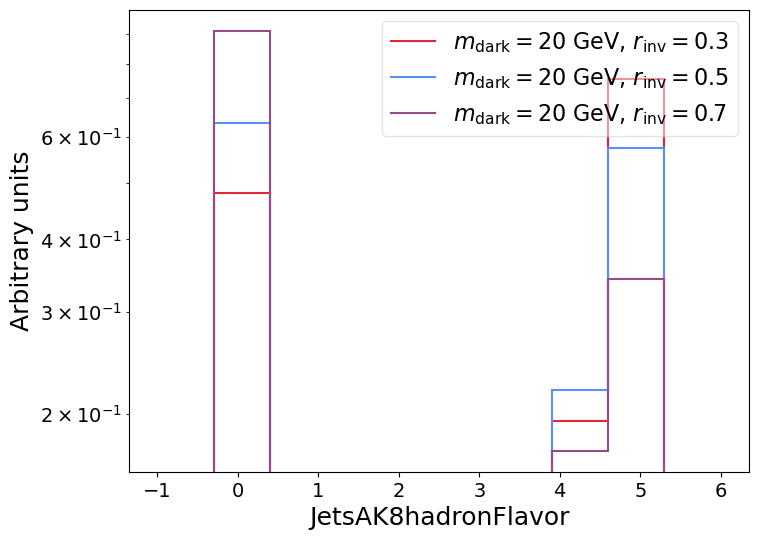

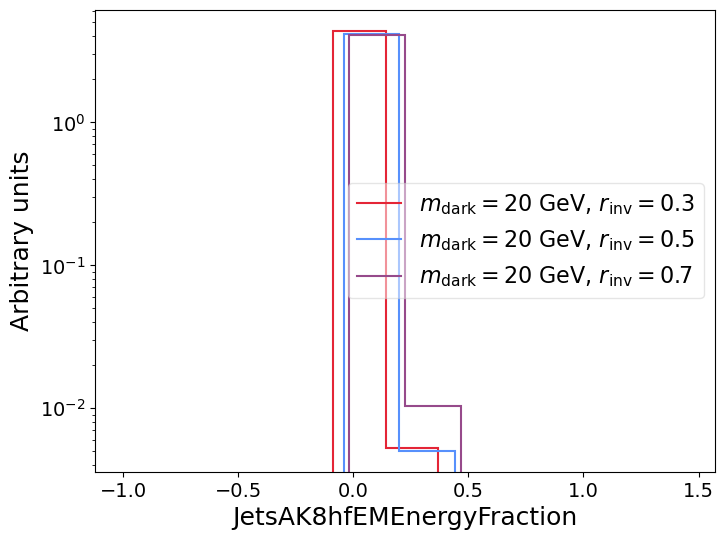

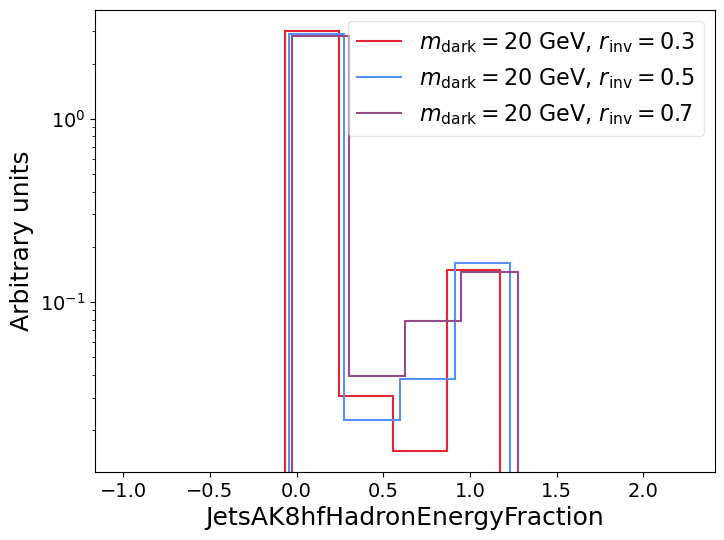

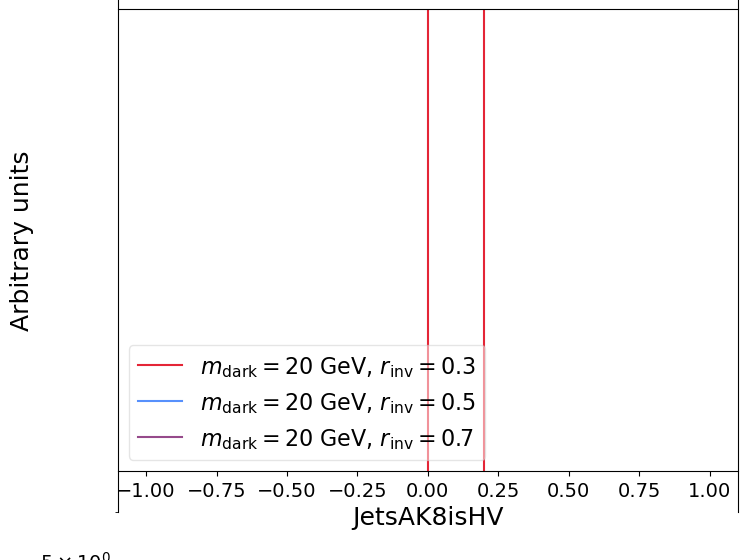

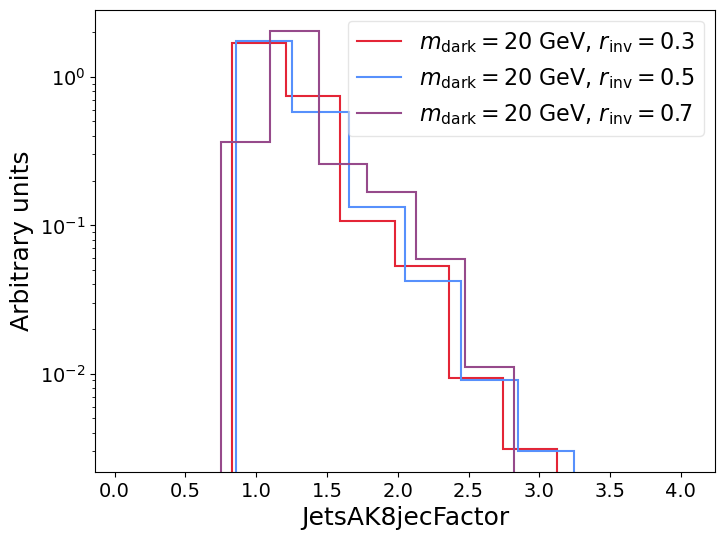

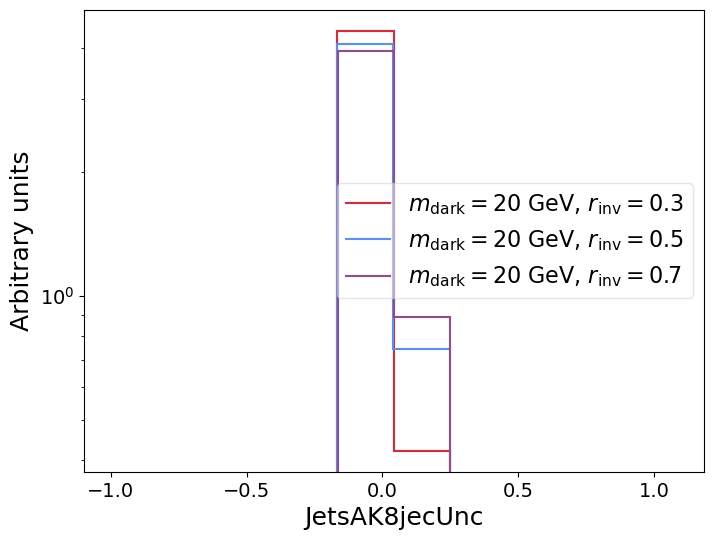

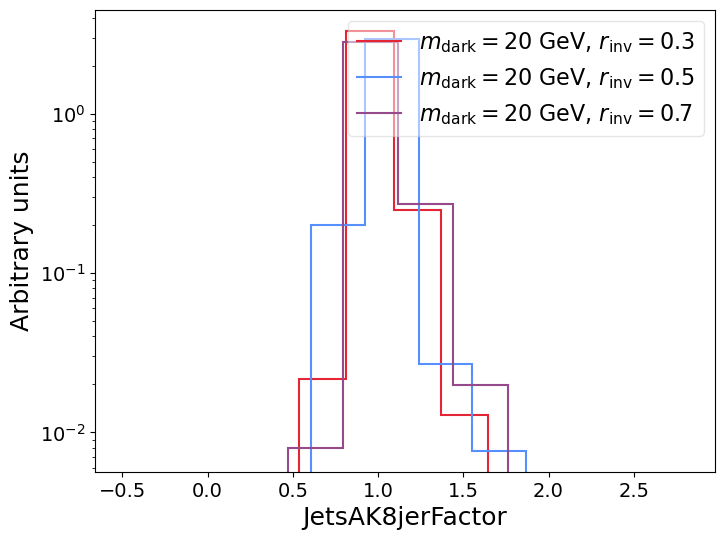

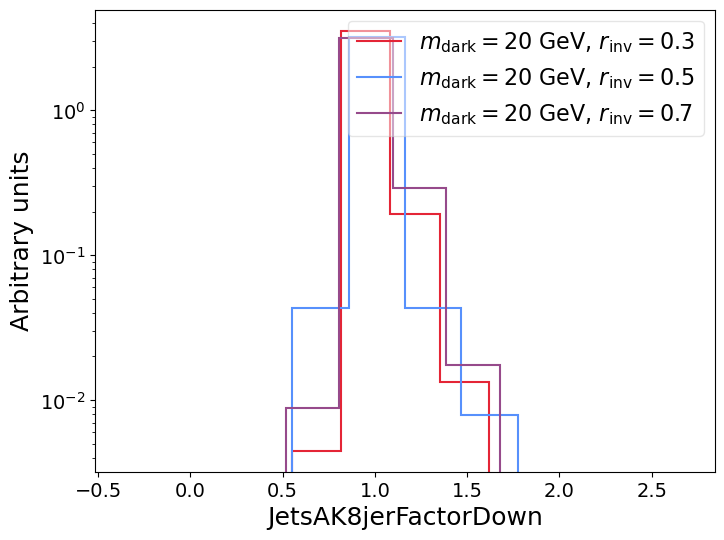

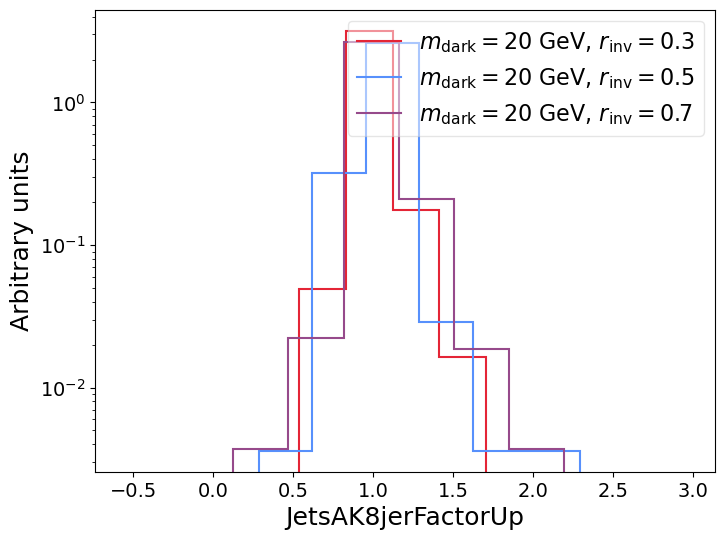

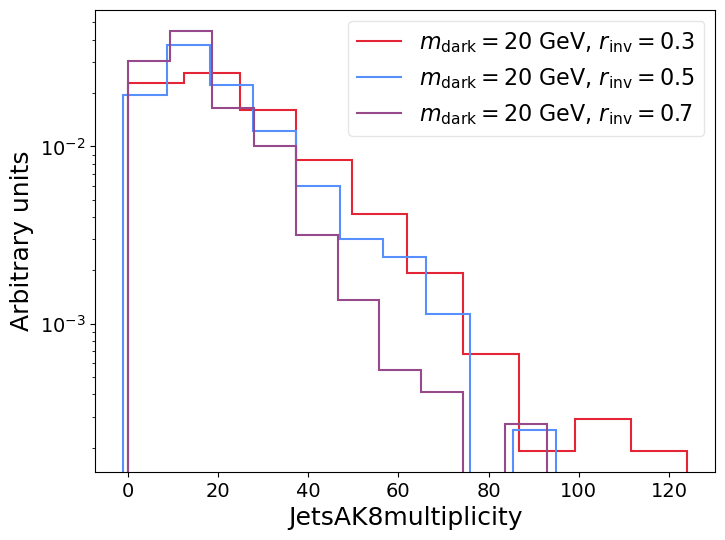

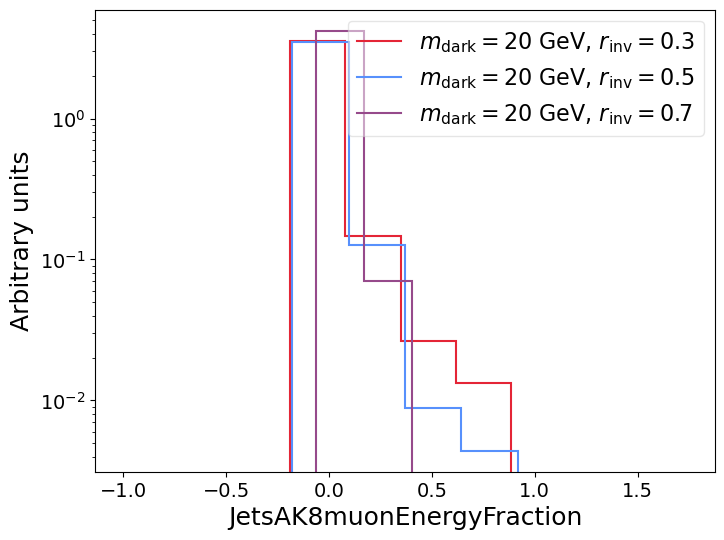

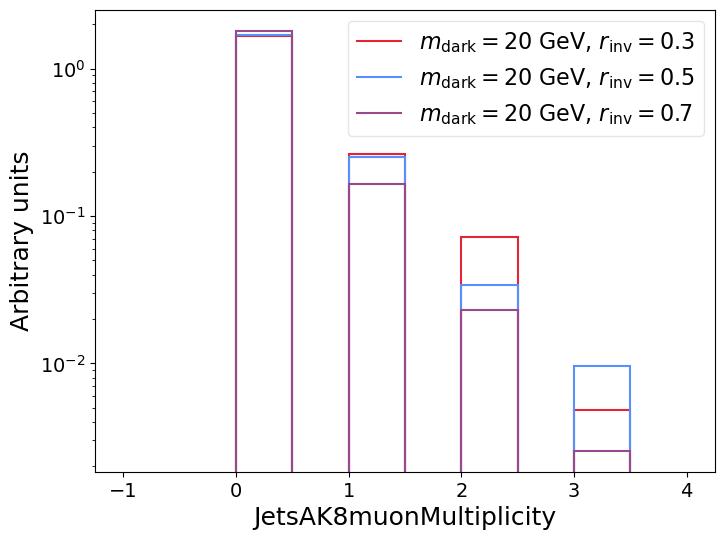

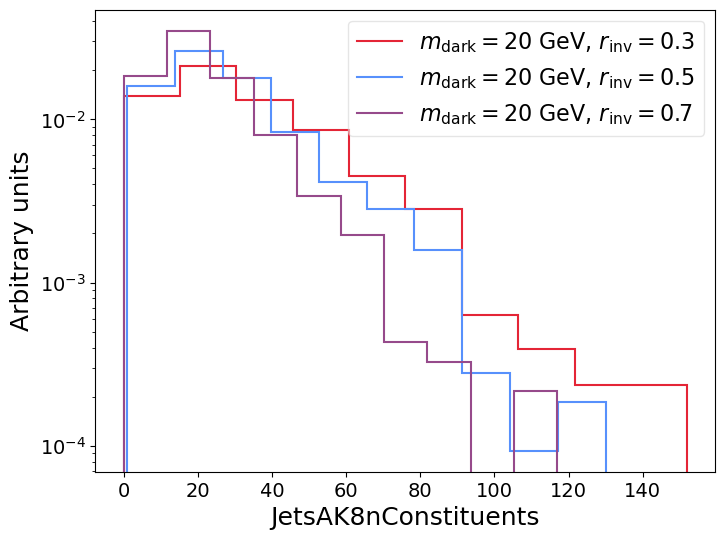

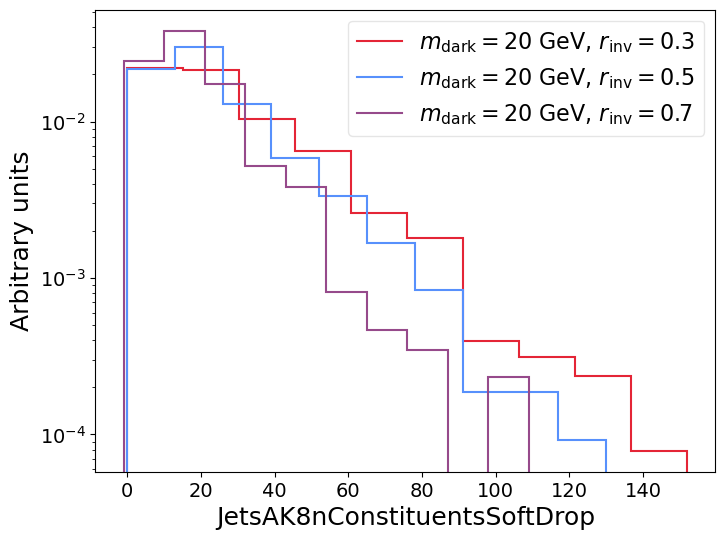

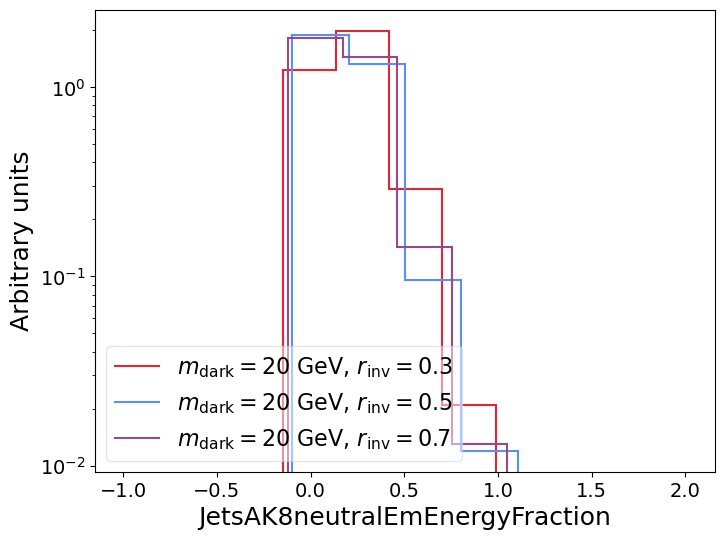

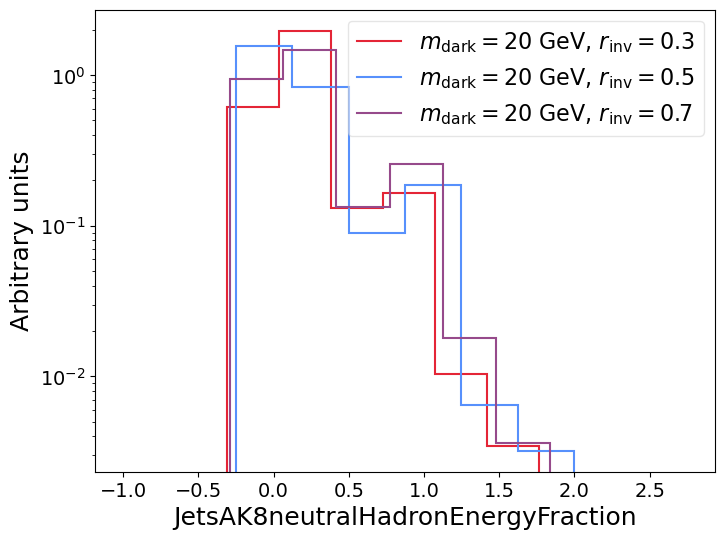

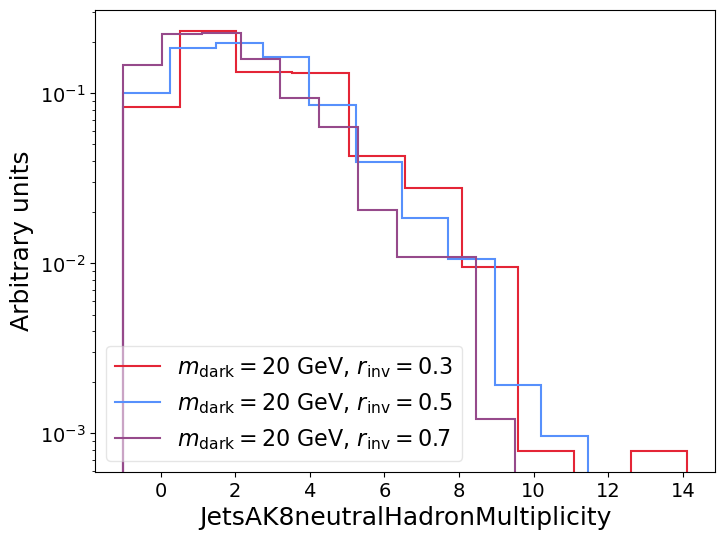

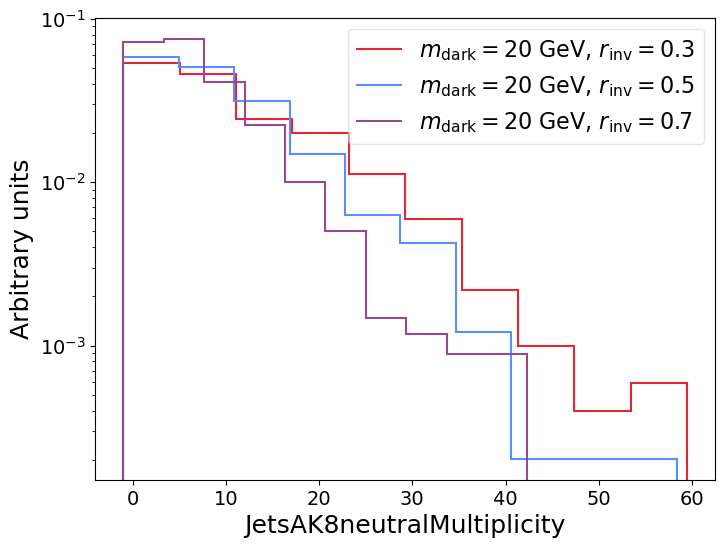

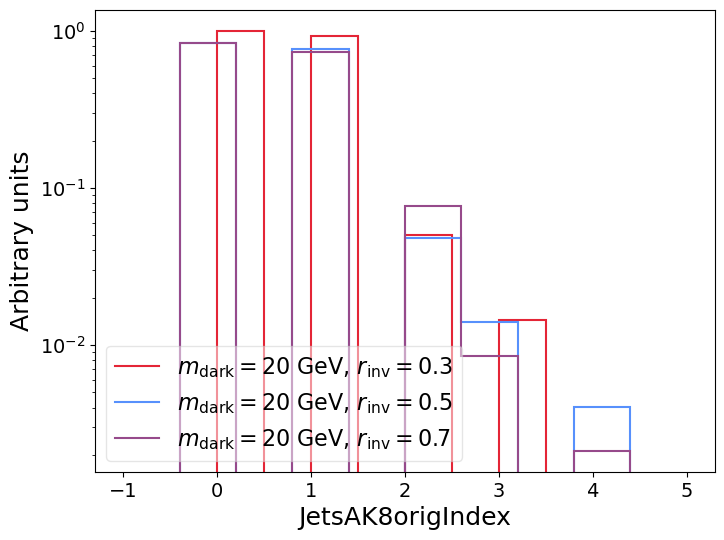

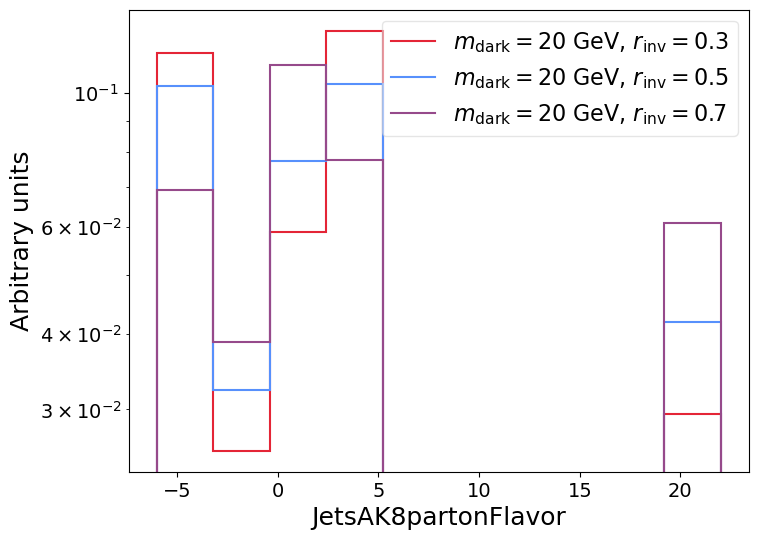

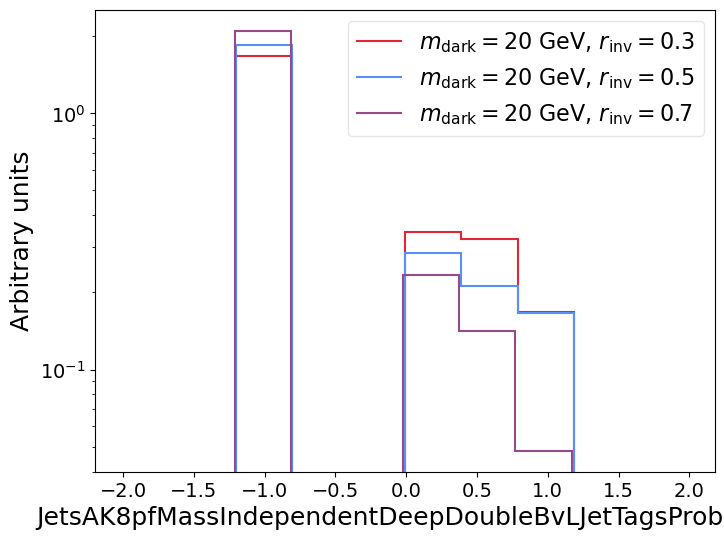

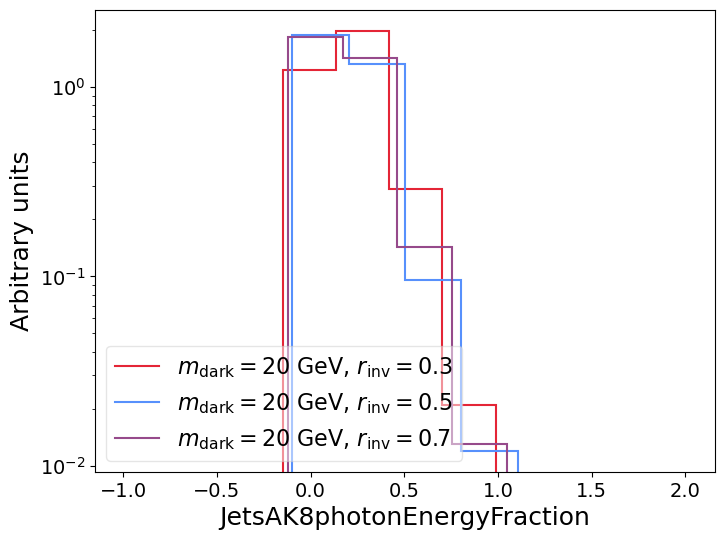

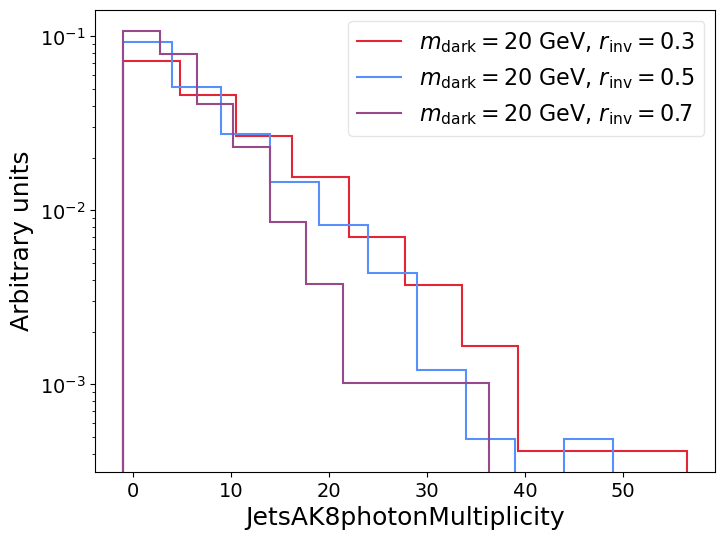

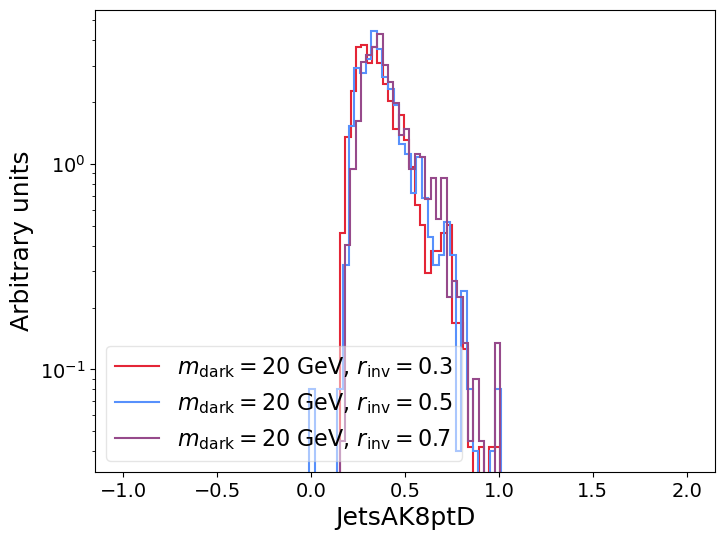

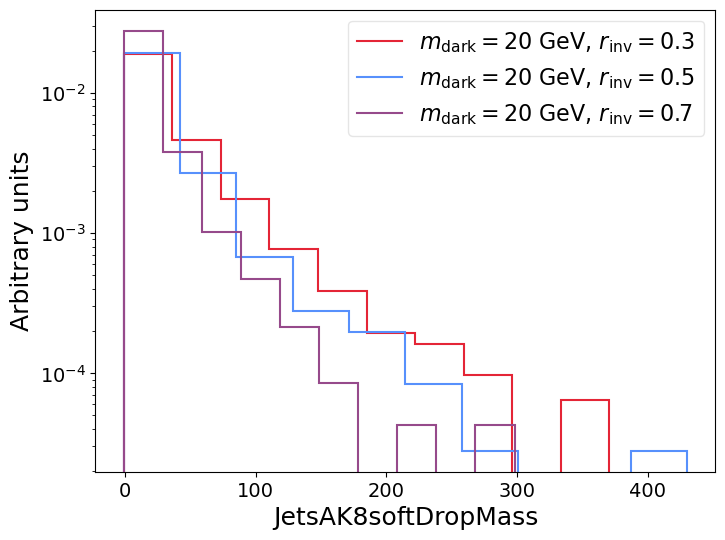

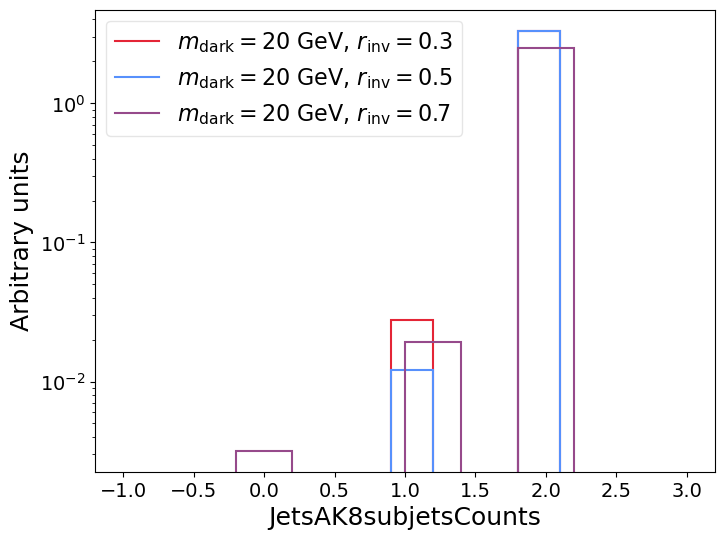

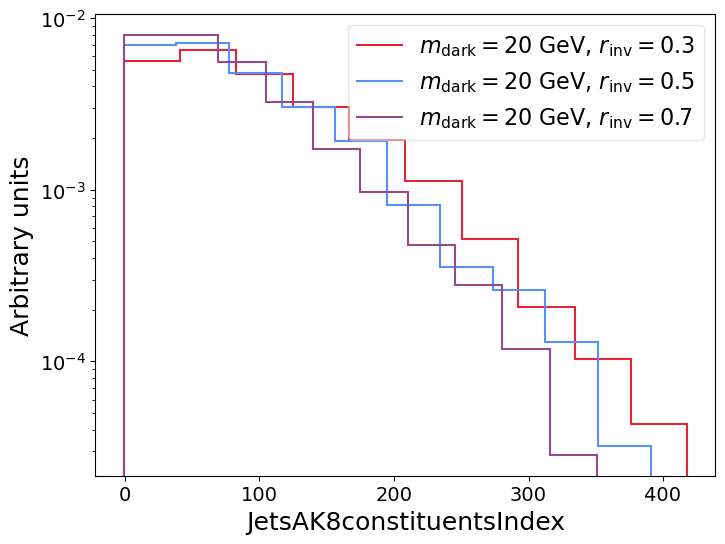

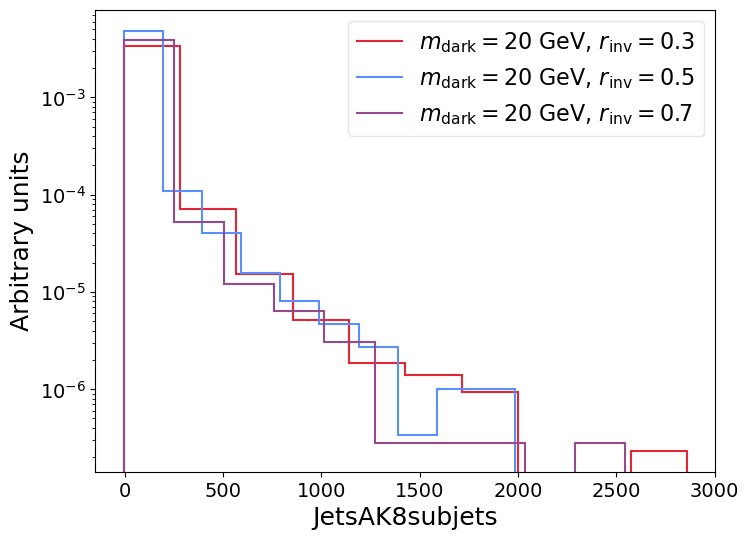

In [40]:
for hname,hists in allhists:
#     print(hname)
    fig, ax = plt.subplots(figsize=(8,6))
    for l,h in hists.items():
        hep.histplot(h,density=True,ax=ax,label=l)

    #ax.set_xlim(0,maximum)
    ax.set_yscale("log")
    ax.set_ylabel("Arbitrary units")
    #ax.set_ylim(1,2e5)
    ax.legend(framealpha=0.5)
    plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')